**Importing libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler, RobustScaler
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score, cross_val_predict, StratifiedShuffleSplit
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from imblearn.ensemble import BalancedRandomForestClassifier, BalancedBaggingClassifier, RUSBoostClassifier, EasyEnsembleClassifier
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler, BorderlineSMOTE, SVMSMOTE, KMeansSMOTE
from imblearn.under_sampling import TomekLinks, RandomUnderSampler, NearMiss, ClusterCentroids
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, precision_score, f1_score, roc_auc_score, recall_score, confusion_matrix
from sklearn.metrics import precision_recall_fscore_support, roc_curve, precision_recall_curve
import pickle
sns.set()

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shivamb/machine-predictive-maintenance-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'machine-predictive-maintenance-classification' dataset.
Path to dataset files: /kaggle/input/machine-predictive-maintenance-classification


Loading data and first impressions

In [4]:
import os
file_path = os.path.join(path, 'predictive_maintenance.csv')
raw_data = pd.read_csv(file_path)
df = raw_data.copy()
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [5]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


Quick insights:

1. There are 10.000 instances in the dataset
2. The are no missing values (every feature has 10.000 observations)
3. Target variable are ones and zeros
4. UDI seems to be an index number
5. Product ID is an identification number. Hence, it can be removed

In [6]:
# Checking unique values for 'UDI' and 'Product ID'
print(f"{df['UDI'].nunique()} unique values for 'UDI'")
print(f"{df['Product ID'].nunique()} unique value for 'Pruduct ID'")

10000 unique values for 'UDI'
10000 unique value for 'Pruduct ID'


In [7]:
# Dropping 'UDI' and 'Product ID' from the dataset
df.drop(['UDI', 'Product ID'], axis=1, inplace=True)

In [8]:
# Let's change the name of the columns.
df = df.rename(mapper={'Air temperature [K]': 'Air temperature',
                       'Process temperature [K]': 'Process temperature',
                       'Rotational speed [rpm]': 'Rotational speed',
                       'Torque [Nm]': 'Torque',
                       'Tool wear [min]': 'Tool wear'}, axis=1)

In [9]:
# Taking a look at 'Failure Type' variable
df['Failure Type'].value_counts()

,count
Failure Type,
No Failure,9652
Heat Dissipation Failure,112
Power Failure,95
Overstrain Failure,78
Tool Wear Failure,45
Random Failures,18


This target variable assumes six possible values: no failure, or five different types of failure.

Quick insight: We can see that the dataset is highly unbalanced. Let's further check that with the 'target' variable:

In [10]:
df['Target'].value_counts(normalize=True)

,proportion
Target,
0,0.9661
1,0.0339


The dataset is indeed very unbalanced. We will deal with that later on.

In [11]:
# Rechecking for missing values
df.isna().sum()

,0
Type,0
Air temperature,0
Process temperature,0
Rotational speed,0
Torque,0
Tool wear,0
Target,0
Failure Type,0


In [12]:
df['Type'].value_counts()

,count
Type,
L,6000
M,2997
H,1003


'Type' assumes three possible values. Later on they will be hot or ordinal encoded.

In [13]:
# Taking a look at the data types
df.dtypes

,0
Type,object
Air temperature,float64
Process temperature,float64
Rotational speed,int64
Torque,float64
Tool wear,int64
Target,int64
Failure Type,object


'Type' and 'Failure Type' are strings.

Target variables

There are two target variables: 'Target' and 'Failure Type'. Let's dig in a bit to check if everything is ok.

In [14]:
# Checking types of failure
df['Failure Type'].value_counts()

,count
Failure Type,
No Failure,9652
Heat Dissipation Failure,112
Power Failure,95
Overstrain Failure,78
Tool Wear Failure,45
Random Failures,18


There are 5 types of failure + not failure.

Now, let's check if there are inconsistencies between 'Target' and 'Failure Type':

In [15]:
df_failure = df[df['Target'] == 1]
df_failure['Failure Type'].value_counts()

,count
Failure Type,
Heat Dissipation Failure,112
Power Failure,95
Overstrain Failure,78
Tool Wear Failure,45
No Failure,9


WARNING!! 9 values are classified as failure in the 'Target' variable but as No Failure in the 'Failure Type' variable. Let's check in the dataset:

In [16]:
df_failure[df_failure['Failure Type'] == 'No Failure']

,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Target,Failure Type
1437,H,298.8,309.9,1439,45.2,40,1,No Failure
2749,M,299.7,309.2,1685,28.9,179,1,No Failure
4044,M,301.9,310.9,1419,47.7,20,1,No Failure
4684,M,303.6,311.8,1421,44.8,101,1,No Failure
5536,M,302.3,311.8,1363,54.0,119,1,No Failure
5941,L,300.6,310.7,1438,48.5,78,1,No Failure
6478,L,300.5,309.8,1663,29.1,145,1,No Failure
8506,L,298.4,309.6,1710,27.3,163,1,No Failure
9015,L,297.2,308.1,1431,49.7,210,1,No Failure


It could go both ways, either failure or no failure. I think it would make sense to remove those instances since I do not know the real target here

In [17]:
index_possible_failure = df_failure[df_failure['Failure Type'] == 'No Failure'].index
df.drop(index_possible_failure, axis=0, inplace=True)

Let's check the same but for 'Target' variable equal to zero (no failure):

In [18]:
df_failure = df[df['Target'] == 0]
df_failure['Failure Type'].value_counts()

,count
Failure Type,
No Failure,9643
Random Failures,18


Second warning!! Similarly, we have 18 instances classifed as Random Failures by 'Failure Type', whereas they are classifed as No failure by the 'Target Variable'. These 18 instances are in fact all instaces of 'Random Failures'. Again, let's check and remove those instances as we do not really know if they belong to Failure class or not. Hence, we will end up with 4 types of failures since 'Random Failures' will be removed altogether.

In [19]:
df_failure[df_failure['Failure Type'] == 'Random Failures']

,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Target,Failure Type
1221,M,297.0,308.3,1399,46.4,132,0,Random Failures
1302,L,298.6,309.8,1505,45.7,144,0,Random Failures
1748,H,298.4,307.7,1626,31.1,166,0,Random Failures
2072,L,299.6,309.5,1570,35.5,189,0,Random Failures
2559,L,299.3,309.0,1447,50.4,140,0,Random Failures
3065,M,300.1,309.2,1687,27.7,95,0,Random Failures
3452,H,301.6,310.5,1602,32.3,2,0,Random Failures
5471,L,302.7,312.3,1346,61.2,170,0,Random Failures
5489,L,302.6,312.1,1499,35.0,215,0,Random Failures
5495,H,302.9,312.5,1357,55.0,12,0,Random Failures


In [20]:
index_possible_failure = df_failure[df_failure['Failure Type'] == 'Random Failures'].index
df.drop(index_possible_failure, axis=0, inplace=True)

In [21]:
# We can check that all 27 instances were removed from the dataset:
df.shape[0]

9973

In [22]:
# Let's reset the index
df.reset_index(inplace=True, drop=True)

# Explanatory Data Analysis (EDA)

**Correlation**

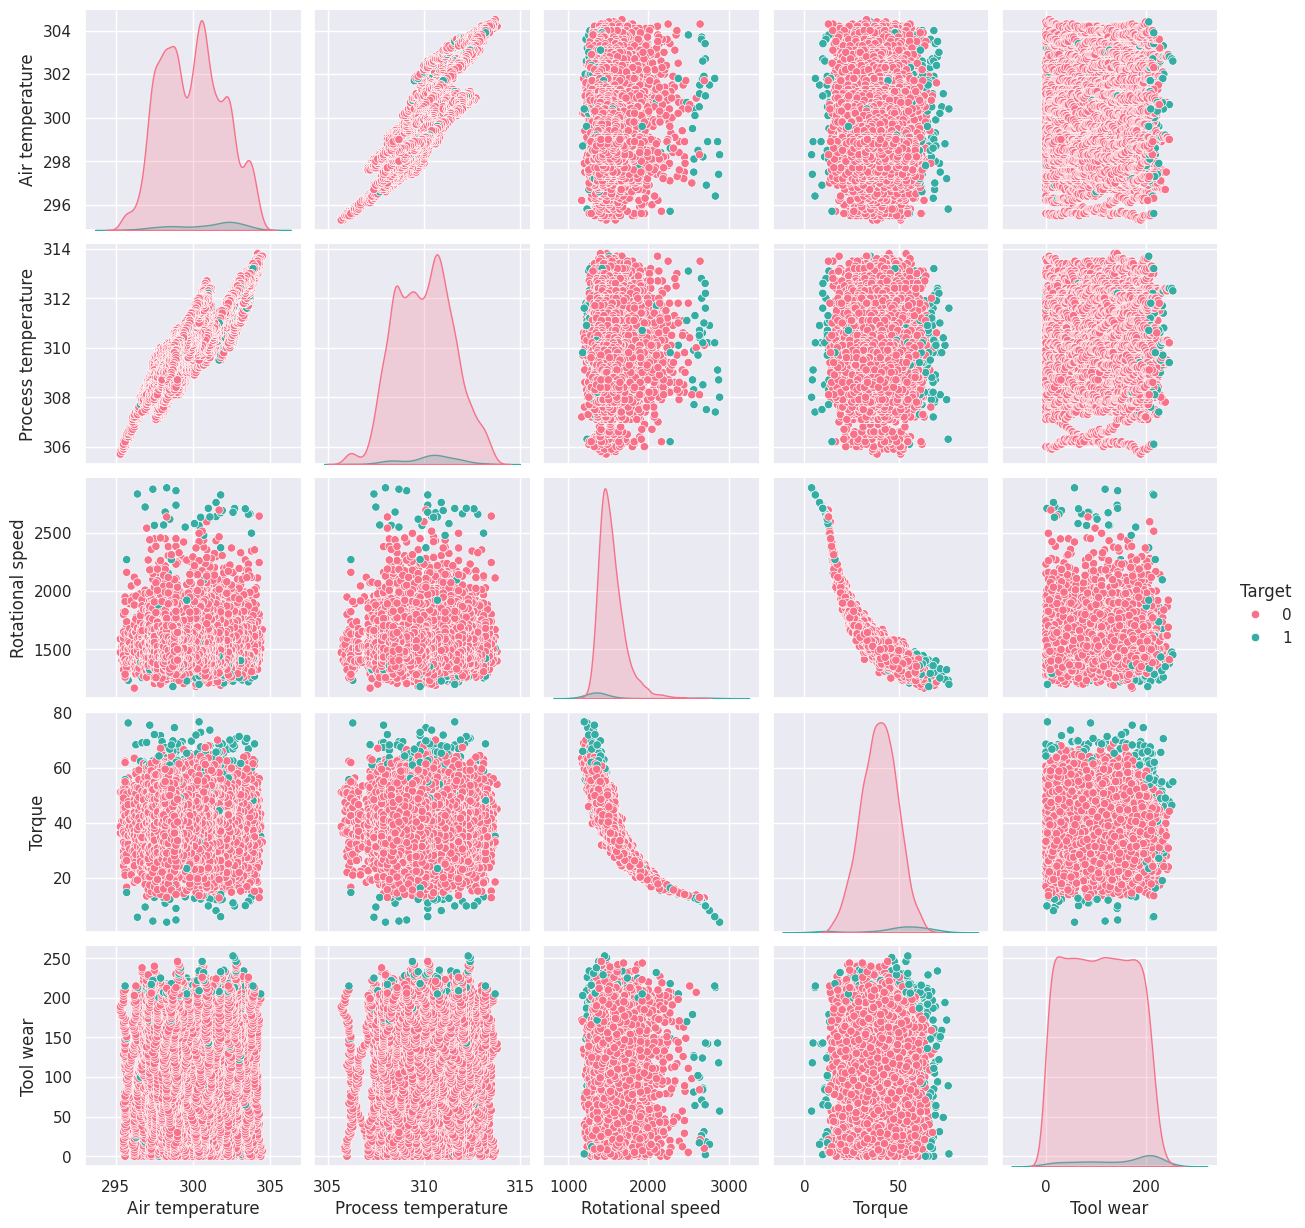

In [23]:
sns.pairplot(df, hue='Target', palette='husl')

Insights:

Torque and rotational speed are highly correlated.
Process temperature and air temperature are also highly correlated.
We immediately see that failures occur for extreme values of some features, i.e., the machinery fails either for the lowest or largest values of torque and rotational speed. This is easily spotted in the graph since the green dots are far apart for those features. So, there is a range for normal conditions in which the machines operate, and above or under this range, they tend to fail.
Let's plot a violin chart to see how torque and rotational speed behave:

/tmp/ipykernel_975/4015366238.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Target', y=i, ax=axes[j], palette='husl')
/tmp/ipykernel_975/4015366238.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Target', y=i, ax=axes[j], palette='husl')


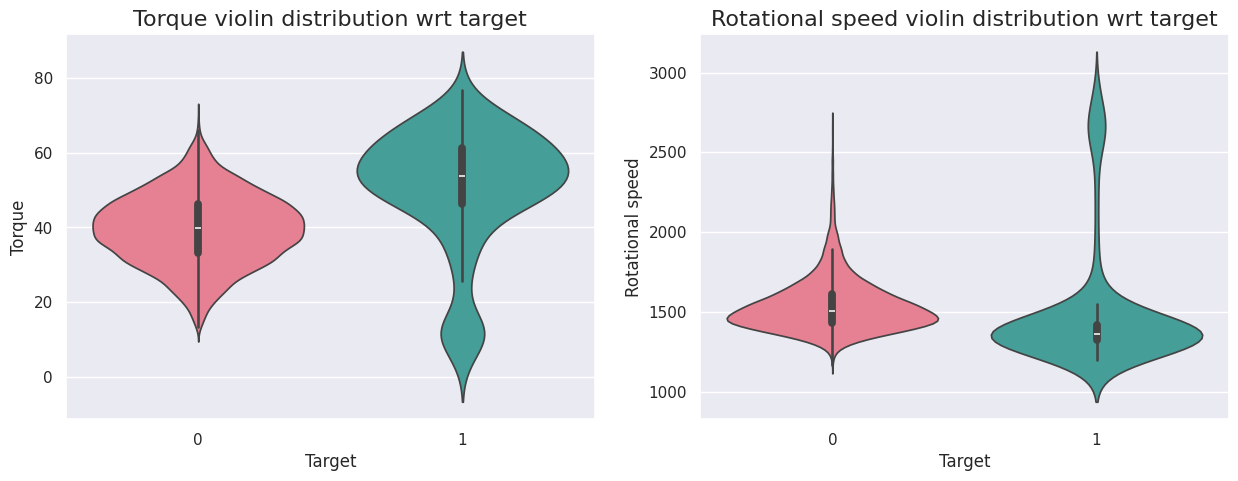

In [24]:
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 16

fig, axes = plt.subplots(1, 2, figsize=[15,5])
axes = axes.flatten()
j=0

for i in ['Torque', 'Rotational speed']:
    sns.violinplot(data=df, x='Target', y=i, ax=axes[j], palette='husl')
    axes[j].set_title(i + ' violin distribution wrt target', )
    j += 1

Insight: Regarding torque and rotational speed, it can be seen again that most failures are triggered for much lower or much higher values than the mean when not failing.

**Percentage of failure**

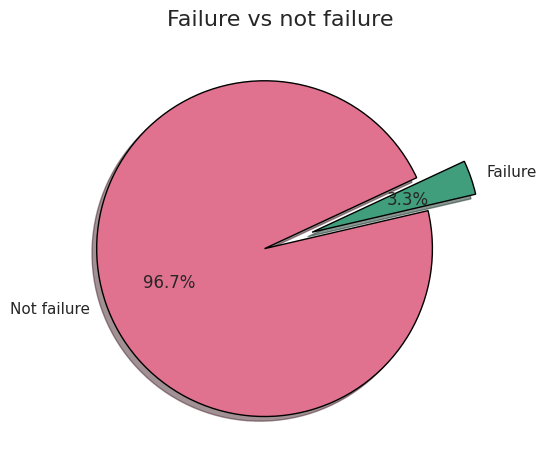

In [25]:
colors = ['#E1728F', '#409E7D']
plt.pie(df['Target'].value_counts(),  explode=[0.1, 0.2], labels=['Not failure', 'Failure'],
        autopct='%1.1f%%', wedgeprops={'edgecolor': 'black'}, shadow=True, startangle=25,
        colors=colors)
plt.title('Failure vs not failure')
plt.tight_layout()
plt.show()

Insight: as mentioned before, highly unbalanced dataset.

Correllation Heatmap

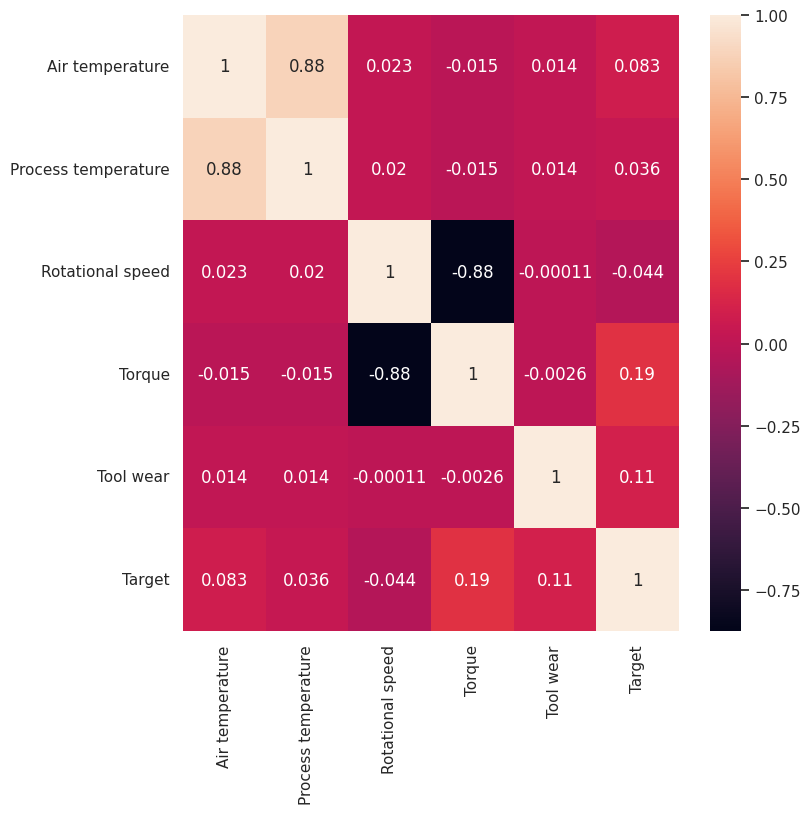

In [26]:
plt.figure(figsize=(8, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True)
plt.show()

As mentioned before, there is high correlation between process temperature and air temperature, and between rotational speed and torque.

**Product types**

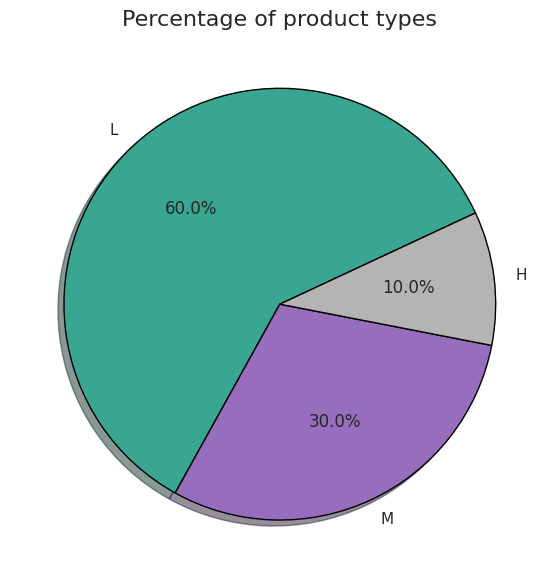

In [27]:
plt.rcParams["figure.figsize"] = (6,6)
colors = ['#39A692', '#976EBD', '#B4B5B2']
plt.pie(df['Type'].value_counts(), labels=['L', 'M', 'H'], colors=colors,
    autopct='%1.1f%%', wedgeprops={'edgecolor': 'black'}, shadow=True, startangle=25)

plt.title('Percentage of product types')
plt.tight_layout()

**Percentage of failure wrt product type**

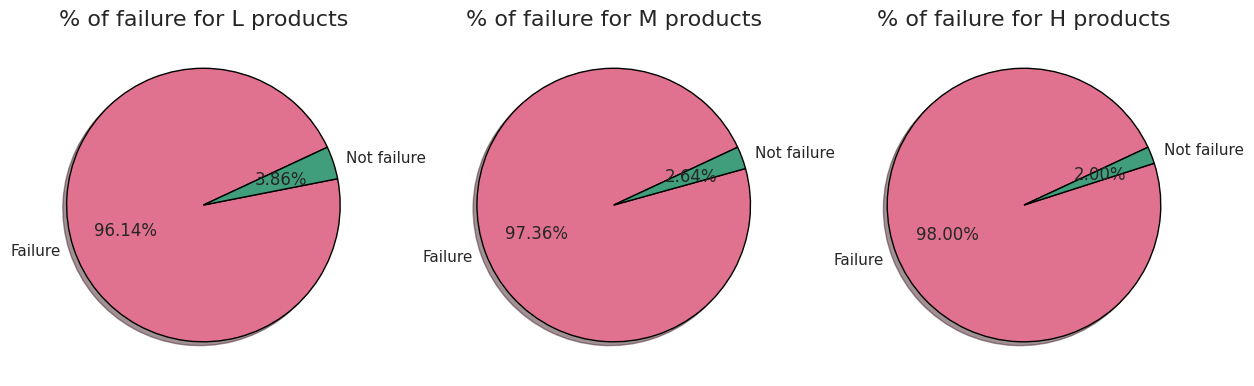

In [28]:
fig, axes = plt.subplots(1,3, figsize=[15,5])
axes.flatten()
j=0
colors = ['#E1728F', '#409E7D']
for i in ['L', 'M', 'H']:
    df_product_type = df[df['Type'] == i]
    axes[j].pie(df_product_type['Target'].value_counts(), labels=['Failure', 'Not failure'],
                autopct='%1.2f%%', wedgeprops={'edgecolor': 'black'}, shadow=True, startangle=25,
                colors=colors)
    axes[j].set_title('% of failure for ' + i + ' products')
    j+=1

Insight: L products have a higher ratio of failure compared to the other product types. Moreover, M tends to fail more than H products.

**Percentage of failure types**

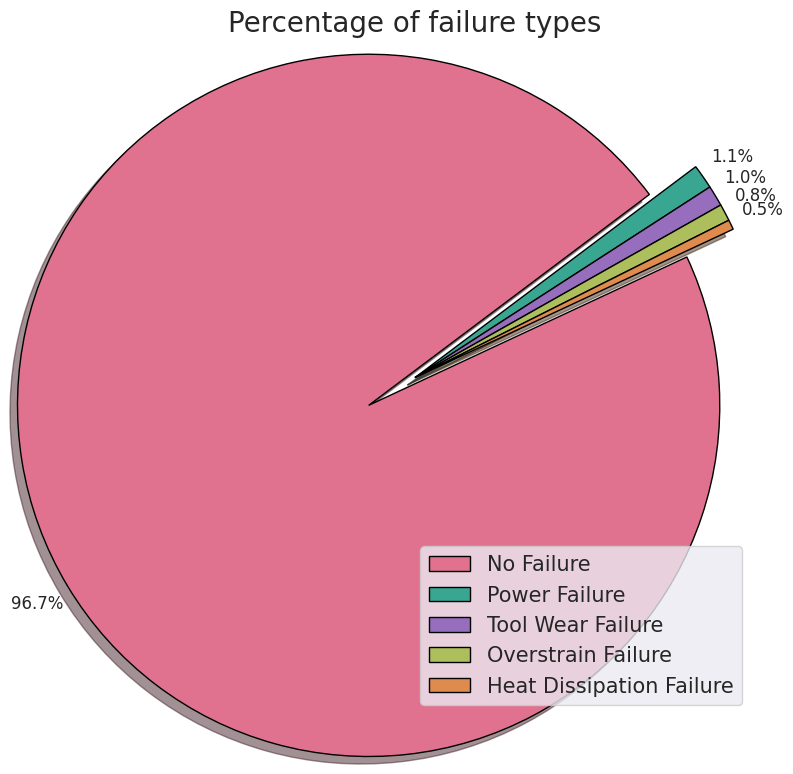

In [29]:
columns_failure_type = df['Failure Type'].unique().tolist()  # Types of failures

plt.rcParams["figure.figsize"] = (8,8)
colors = ['#E1728F', '#39A692', '#976EBD', '#ACBF5C', '#DF8B4E']

plt.pie(df['Failure Type'].value_counts(), explode=(0.2, 0, 0, 0, 0), autopct='%1.1f%%',
        wedgeprops={'edgecolor': 'black'}, counterclock=False, shadow=True, startangle=25,
        pctdistance=1.1, radius=1.3, colors=colors)
plt.legend(columns_failure_type, loc='lower right', fontsize=15)

plt.title('Percentage of failure types', fontsize=20)
plt.tight_layout()

**Exploring features for each type of failure**

Text(0.5, 1.0, 'Excluding class no failure')

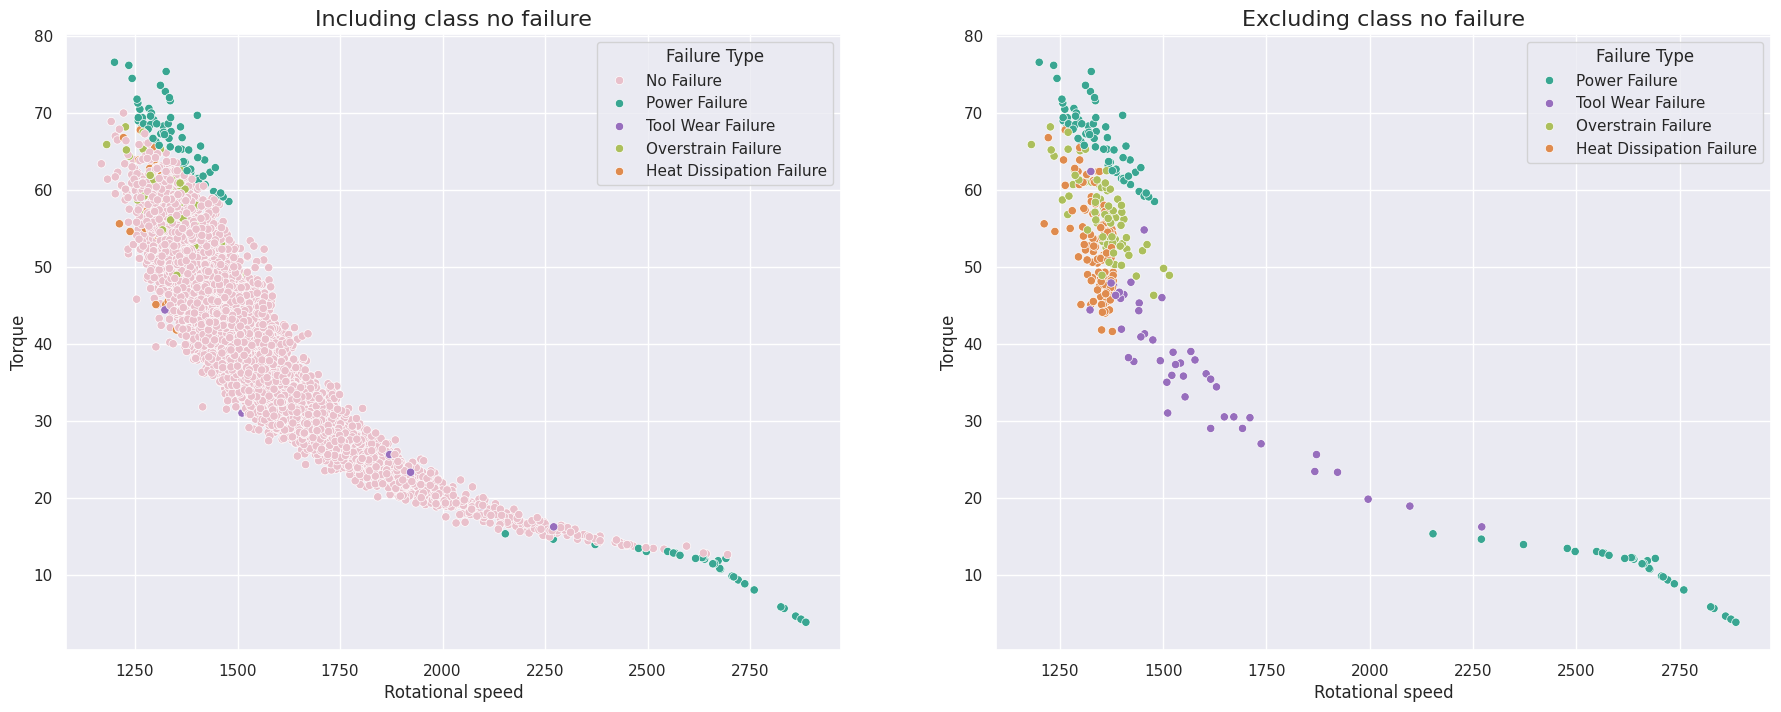

In [30]:
fig, ax = plt.subplots(1,2, figsize=[22,8])
plt.title('Rot. Speed vs Torque wrt Failure Type')
sns.scatterplot(data=df, x='Rotational speed', y='Torque', hue='Failure Type', palette=['#E9C0CB', '#39A692', '#976EBD', '#ACBF5C', '#DF8B4E'], ax=ax[0])
sns.scatterplot(data=df[df['Target'] == 1], x='Rotational speed', y='Torque', hue='Failure Type', palette=['#39A692', '#976EBD', '#ACBF5C', '#DF8B4E'], ax=ax[1])

ax[0].set_title('Including class no failure')
ax[1].set_title('Excluding class no failure')

Some insights:

Power failure happens both for lower and higher rotational speed/torque. It is the type of failure with the highest rotational speed (over 2500rpm) and lowest torque (below around 15Nm). In other others, above and below these thresholds only power failures occur.
Between torques 16Nm and 41Nm all failures are tool wear.
Overstrain failures take place with torques ranging from around 47 and 68Nm) and rotational speeds from 1200 to 1500rpm approximately.
For heat dissipation failures, the torque range is smaller and the rotational speed range is bigger compared to overstrain failures.

**Distribution**

----- SKEWNESS ------------


/tmp/ipykernel_975/1531974068.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=i, ax=axes[1,j], palette=['#976EBD'])


Air temperature skewness = 0.12


/tmp/ipykernel_975/1531974068.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=i, ax=axes[1,j], palette=['#976EBD'])


Process temperature skewness = 0.02


/tmp/ipykernel_975/1531974068.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=i, ax=axes[1,j], palette=['#976EBD'])


Rotational speed skewness = 1.99


/tmp/ipykernel_975/1531974068.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=i, ax=axes[1,j], palette=['#976EBD'])
/tmp/ipykernel_975/1531974068.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=i, ax=axes[1,j], palette=['#976EBD'])


Torque skewness = -0.01
Tool wear skewness = 0.03
---------------------------


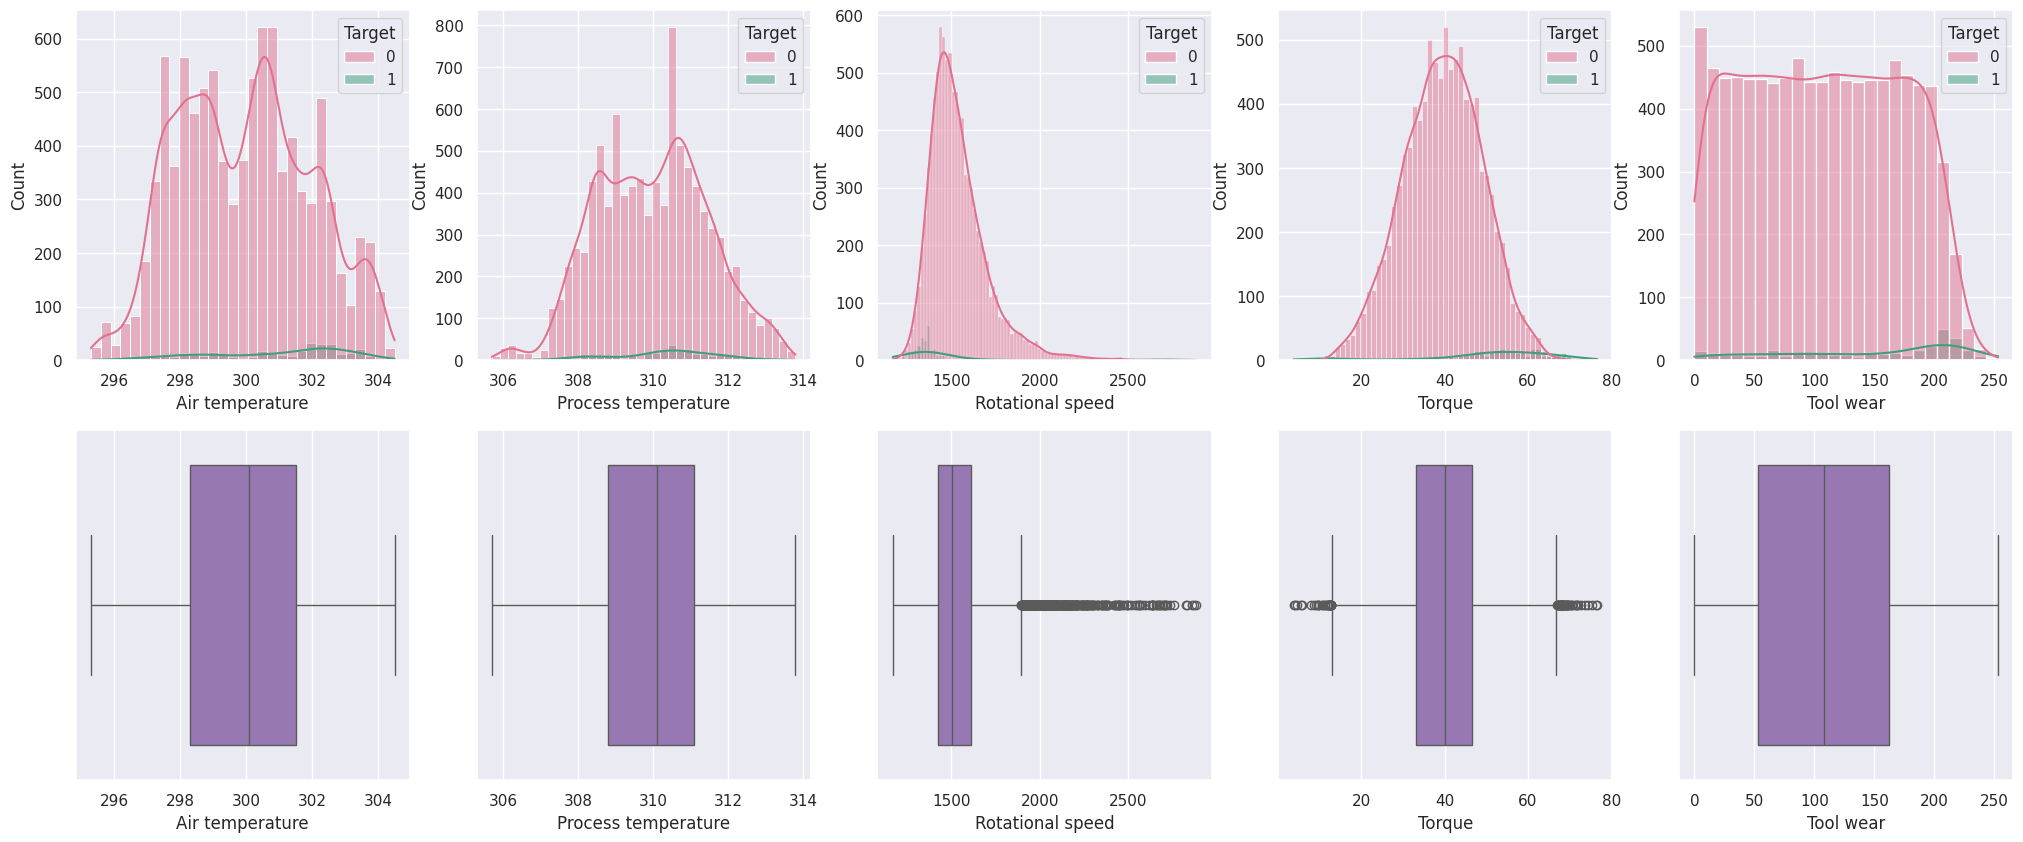

In [31]:
print('----- SKEWNESS ------------')
fig, axes = plt.subplots(2, 5, figsize=[25,10])
j = 0
colors = ['#E1728F', '#409E7D']

for i in ['Air temperature', 'Process temperature', 'Rotational speed', 'Torque', 'Tool wear']:
    sns.histplot(data=df, x=i, kde=True, ax=axes[0,j], hue='Target', palette=colors)
    sns.boxplot(data=df, x=i, ax=axes[1,j], palette=['#976EBD'])
    j+=1
    print('{} skewness = {}'.format(i, round(df[i].skew(), 2)))
print('---------------------------')

* Rotational speed is positively skewed.
* From the boxplots we can see that 'Rotational speed' and 'Torque' have outliers.

Let's check those potential 'outliers' by analyzing the boxplots:

In [32]:
# Function to calculate the maximum and minumum value from the boxplot
def maximum_box(x):
    Q1 = x.quantile(0.25)
    Q3 = x.quantile(0.75)
    IQR = Q3 - Q1
    maximum = Q3 + 1.5*IQR
    minimum = Q1 - 1.5*IQR
    return maximum, minimum

for i in ['L', 'M', 'H']:
    df_product_type = df[df['Type'] == i]
    max_rotational_speed, min_rotational_speed = maximum_box(df_product_type['Rotational speed'])
    max_torque, min_torque = maximum_box(df_product_type['Torque'])
    print('Values from boxplot for type product ' + i + ':')
    print(f'Maximum torque value: {round(max_torque,2)}')
    print(f'Minimum torque value: {round(min_torque,2)}')
    print(f'Maximum rotational speed value: {round(max_rotational_speed,2)}')
    print(f'Minimum rotational speed value: {round(min_rotational_speed,2)}')
    print('='*20)

Values from boxplot for type product L:
Maximum torque value: 67.2
Minimum torque value: 12.8
Maximum rotational speed value: 1894.0
Minimum rotational speed value: 1142.0
Values from boxplot for type product M:
Maximum torque value: 67.05
Minimum torque value: 13.05
Maximum rotational speed value: 1895.75
Minimum rotational speed value: 1137.75
Values from boxplot for type product H:
Maximum torque value: 66.96
Minimum torque value: 12.66
Maximum rotational speed value: 1894.38
Minimum rotational speed value: 1143.38


Insight: The operational range for torque and rotational speed are similar for all product types.

Values above the maximum and below the minimum might be outliers, but not necessarily.

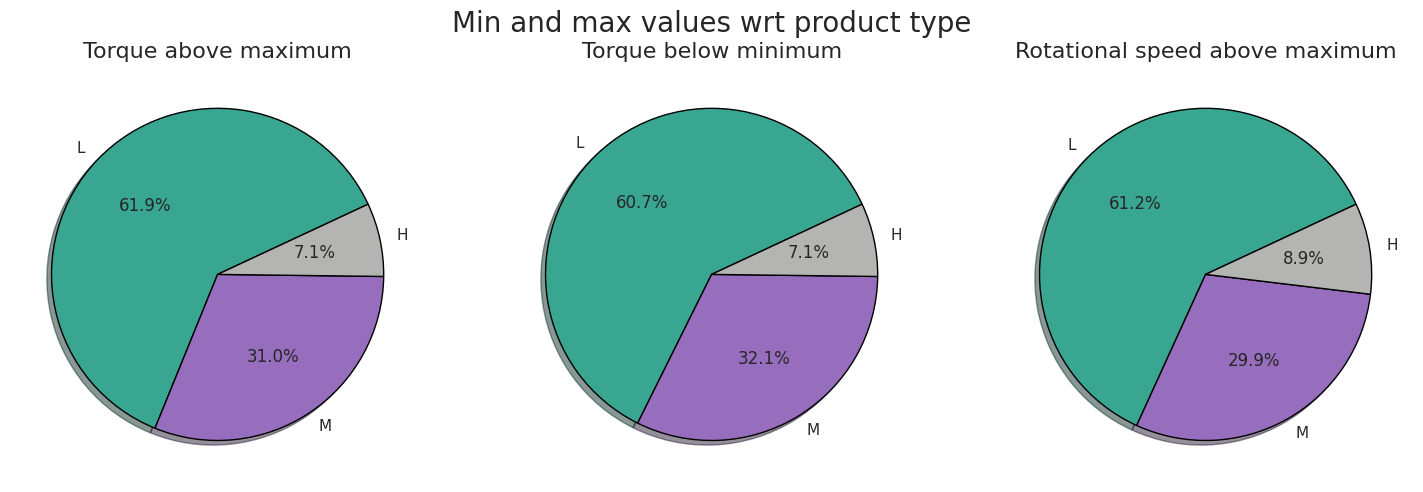

In [33]:
max_rotational_speed, min_rotational_speed = maximum_box(df['Rotational speed'])
max_torque, min_torque = maximum_box(df['Torque'])

max_torque_values = df[df['Torque'] >= max_torque]['Type'].value_counts()  # Torque values above the boxplot maximum
min_torque_values = df[df['Torque'] <= min_torque]['Type'].value_counts()  # Torque values below the boxplot minimum
max_rotational_speed_values = df[df['Rotational speed'] >= max_rotational_speed]['Type'].value_counts()  # Rotational spede values above the boxplot maximum

fig, axes = plt.subplots(1,3, figsize=[15,5])
fig.suptitle('Min and max values wrt product type', fontsize=20)
plt.rcParams['axes.titlesize'] = 16
axes.flatten()
j=0
colors = ['#39A692', '#976EBD', '#B4B5B2']

for i in [max_torque_values, min_torque_values, max_rotational_speed_values]:
    axes[j].pie(i, labels=['L', 'M', 'H'], colors=colors,
        autopct='%1.1f%%', wedgeprops={'edgecolor': 'black'}, shadow=True, startangle=25)
    j+=1

axes[0].set_title('Torque above maximum')
axes[1].set_title('Torque below minimum')
axes[2].set_title('Rotational speed above maximum')
plt.tight_layout()

**Insight:** The values above the maximum and below the minimum are not highly correlated with the product type. The proportion of the pies is similar to the 60-30-10 proportion of the entire dataset.

However, there are proportionally slightly more values for L products and less for H across the three scenarios.

In [34]:
total_max_min_values = max_torque_values.sum() + min_torque_values.sum() + max_rotational_speed_values.sum()  # Total of instance under and above the minimum and maximum threshold from the boxplot, respectively.
ratio = total_max_min_values/df.shape[0]  # Percetange of these values with respect to the entire dataset
print('Percentage of values under and above the minimum and maximum threshold from the boxplot: {}'.format(ratio))

Percentage of values under and above the minimum and maximum threshold from the boxplot: 0.048932116715130855


**Insight:** 4.87% of the instances could be considered as ouliers using the boxplot method.

<span style="color:#26488F; font-size:28px; font-weight: bold;">  Data Preprocessing </span>

In [35]:
columns_failure_type = df['Failure Type'].unique().tolist()

<span style="color:#26488F; font-size:22px; font-weight: bold;">  Ordinal Encoding </span>

In [36]:
# Pass on the categorical values
ord_enc = OrdinalEncoder(categories=[['L', 'M', 'H'], columns_failure_type])

# Fit and transform the data for feature 'Type' and target 'Failure Type'
new_dat = ord_enc.fit_transform(df[['Type', 'Failure Type']])
new_dat
df.drop(['Type', 'Failure Type'], axis=1, inplace=True)

new_df = pd.DataFrame(new_dat,
                      index=df.index,
                      columns=['Type', 'Failure Type'])

df = pd.concat([df, new_df], axis=1)

<span style="color:#26488F; font-size:22px; font-weight: bold;">  Scaling data </span>

Since 'Rotational spede' and 'Torque' have some outliers, I am going to use RobustScaler:

In [37]:
df_scaled = df.copy()

# Scaling Rotational speed and torque with robust scaler:
columns = ['Rotational speed', 'Torque']
scaler = RobustScaler()
features_scaled = scaler.fit_transform(df[columns])
features_scaled = pd.DataFrame(features_scaled, columns=columns)
df_scaled.drop(columns, axis=1, inplace=True)
df_scaled = pd.concat([df_scaled,features_scaled], axis=1)

df_scaled.head(5)

,Air temperature,Process temperature,Tool wear,Target,Type,Failure Type,Rotational speed,Torque
0,298.1,308.6,0,0,1.0,0.0,0.253968,0.200000
1,298.2,308.7,3,0,0.0,0.0,-0.502646,0.459259
2,298.1,308.5,5,0,0.0,0.0,-0.026455,0.688889
3,298.2,308.6,7,0,0.0,0.0,-0.370370,-0.044444
4,298.2,308.7,9,0,0.0,0.0,-0.502646,-0.007407


The rest of the features will be scaled with MinMax scaling:

In [38]:
columns = ['Air temperature', 'Process temperature', 'Tool wear']
scaler = MinMaxScaler()
features_scaled = scaler.fit_transform(df[columns])
features_scaled = pd.DataFrame(features_scaled, columns=columns)
df_scaled.drop(columns, axis=1, inplace=True)
df_scaled = pd.concat([df_scaled, features_scaled], axis=1)

df_scaled.head()

,Target,Type,Failure Type,Rotational speed,Torque,Air temperature,Process temperature,Tool wear
0,0,1.0,0.0,0.253968,0.200000,0.304348,0.358025,0.000000
1,0,0.0,0.0,-0.502646,0.459259,0.315217,0.370370,0.011858
2,0,0.0,0.0,-0.026455,0.688889,0.304348,0.345679,0.019763
3,0,0.0,0.0,-0.370370,-0.044444,0.315217,0.358025,0.027668
4,0,0.0,0.0,-0.502646,-0.007407,0.315217,0.370370,0.035573


<span style="color:#26488F; font-size:28px; font-weight: bold;">  Modeling with 'Target' variable </span>

As the dataset is unbalanced, I am going to used macro f1 score and ROC AUC score to assess model performance.

First, let's build a model with 'Target'. Hence, we need to remove the other target 'Failure Type' to avoid data leakage.

<span style="color:#26488F; font-size:22px; font-weight: bold;">  Stratified Split </span>

In [39]:
X = df_scaled.drop(['Target', 'Failure Type'], axis=1)
y = df_scaled['Target']

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.25, random_state=42)

for train_index, test_index in sss.split(X, y):
    X_train, X_test = X.loc[train_index], X.loc[test_index]
    y_train, y_test = y.loc[train_index], y.loc[test_index]

print('Checking the stratified split...')
print('Target proportion in original dataset:')
print(df['Target'].value_counts(normalize=True))

print('Target proportion in y_train dataset:')
print(y_train.value_counts(normalize=True))

print('Target proportion in y_test dataset:')
print(y_test.value_counts(normalize=True))

Checking the stratified split...
Target proportion in original dataset:
Target
0    0.966911
1    0.033089
Name: proportion, dtype: float64
Target proportion in y_train dataset:
Target
0    0.966974
1    0.033026
Name: proportion, dtype: float64
Target proportion in y_test dataset:
Target
0    0.96672
1    0.03328
Name: proportion, dtype: float64


The proportions are similar. Therefore, it was correctly splitted.

# Balanced Models

Fitting BalancedRandomForestClassifier(n_jobs=-1, random_state=42)
Cross val roc auc test data: 0.9802
Cross val macro f1 score test data: 0.6343
Cross val macro precision score test data: 0.6196
Cross val macro recall score test data: 0.8481

Fitting BalancedBaggingClassifier(n_jobs=-1, random_state=42)
Cross val roc auc test data: 0.9733
Cross val macro f1 score test data: 0.674
Cross val macro precision score test data: 0.6324
Cross val macro recall score test data: 0.8621

Fitting RUSBoostClassifier(random_state=42)
Cross val roc auc test data: 0.806
Cross val macro f1 score test data: 0.575
Cross val macro precision score test data: 0.5587
Cross val macro recall score test data: 0.6852

Fitting EasyEnsembleClassifier(random_state=42)
Cross val roc auc test data: 0.964
Cross val macro f1 score test data: 0.6216
Cross val macro precision score test data: 0.6037
Cross val macro recall score test data: 0.8341



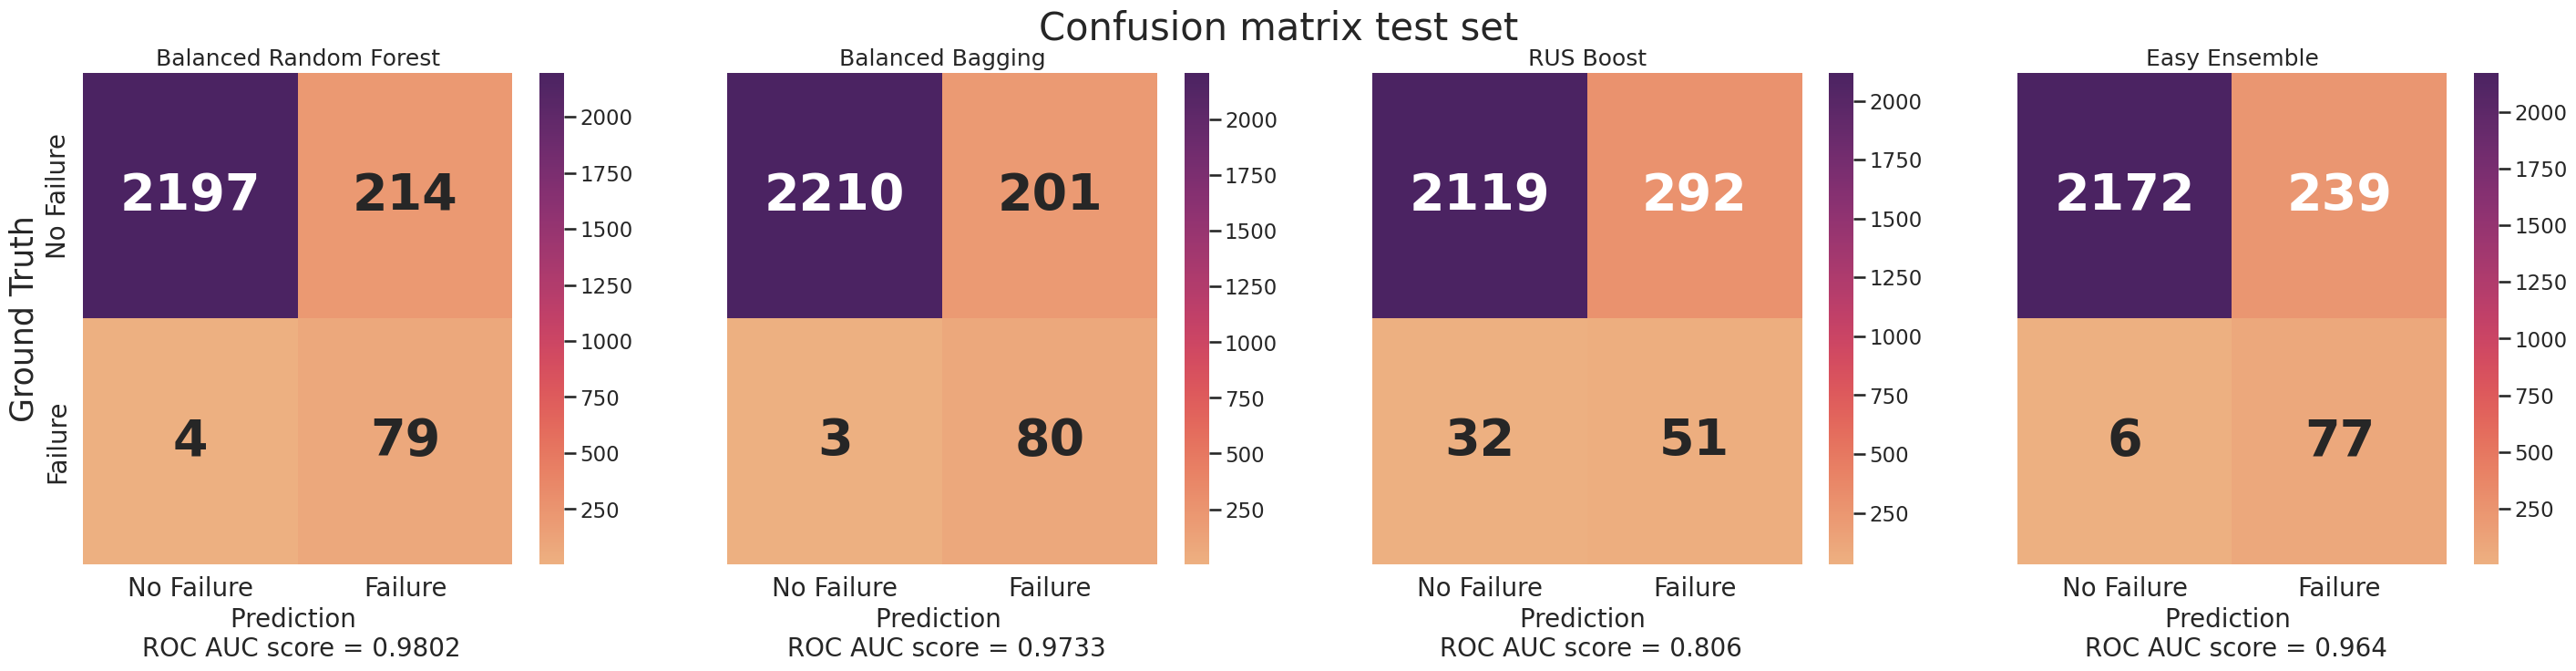

,f1,roc_auc
BalancedBaggingClassifier,0.6740,0.9733
BalancedRandomForestClassifier,0.6343,0.9802
EasyEnsembleClassifier,0.6216,0.9640
RUSBoostClassifier,0.5750,0.8060


In [40]:
from sklearn.model_selection import cross_validate

brfc = BalancedRandomForestClassifier(random_state=42, n_jobs=-1)
bbc = BalancedBaggingClassifier(random_state=42, n_jobs=-1)
RUSB = RUSBoostClassifier(random_state=42)
EEC = EasyEnsembleClassifier(random_state=42)

fig, axes = plt.subplots(1, 4, figsize=[35,7])
fig.suptitle('Confusion matrix test set', fontsize=30)
axes.flatten()
j=0

results_df = pd.DataFrame()

for model in [brfc, bbc, RUSB, EEC]:
    print('Fitting', model)
    model = model.fit(X_train, y_train)

    # Cross validation metrics test data
    cv = StratifiedShuffleSplit(n_splits=5, test_size=0.25, random_state=42)
    y_pred = model.predict(X_test)
    scoring = ["f1_macro", "precision_macro", "recall_macro"]
    cross_val_scores = cross_validate(model, X, y, scoring=scoring)
    roc_auc_test_cv = round(cross_val_score(model, X, y, cv=cv, n_jobs=-1, scoring="roc_auc").mean(),4)
    f1_test_cv = round(cross_val_scores["test_f1_macro"].mean(),4)
    precision_test_cv = round(cross_val_scores["test_precision_macro"].mean(),4)
    recall_test_cv = round(cross_val_scores["test_recall_macro"].mean(),4)

    # Summary table
    score_df = pd.DataFrame({
                     'f1': round(cross_val_scores["test_f1_macro"].mean(),4),
                     'roc_auc': roc_auc_test_cv},
                     index=[str(model).split('(')[0]])

    results_df = pd.concat([results_df, score_df])

    # Print metrics
    print(f'Cross val roc auc test data: {roc_auc_test_cv}')
    print(f'Cross val macro f1 score test data: {round(cross_val_scores["test_f1_macro"].mean(),4)}')
    print(f'Cross val macro precision score test data: {round(cross_val_scores["test_precision_macro"].mean(),4)}')
    print(f'Cross val macro recall score test data: {round(cross_val_scores["test_recall_macro"].mean(),4)}')
    print()

    # Confusion matrix test data
    sns.set_context('talk')
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='flare', annot_kws={"size": 40, "weight": "bold"}, ax=axes[j])

    labels = ['No Failure', 'Failure']
    axes[j].set_xticklabels(labels, fontsize=20)
    axes[j].set_yticklabels(['',''], fontsize=20)
    axes[j].set_xlabel('Prediction \n ROC AUC score = ' + str(roc_auc_test_cv), fontsize=20)
    j += 1

axes[0].set_yticklabels(labels, fontsize=20)
axes[0].set_ylabel('Ground Truth', fontsize=25)
axes[0].set_title('Balanced Random Forest')
axes[1].set_title('Balanced Bagging')
axes[2].set_title('RUS Boost')
axes[3].set_title('Easy Ensemble')
plt.show()

results_df = results_df.sort_values(by='f1', ascending=False)
results_df.round(4)

All results are using cross validation:
- **Balanced Bagging is the best overall model**, with highest f1 score and second highest roc auc.
- Balanced Random Forest has a slightly highest roc auc than Balanced Bagging, but its f1 score is lower.
- Easy Ensemble has a high roc auc thant Balance Bagging, but very low f1 score.

All results are using cross validation:
- **Balanced Bagging is the best overall model**, with highest f1 score and second highest roc auc.
- Balanced Random Forest has a slightly highest roc auc than Balanced Bagging, but its f1 score is lower.
- Easy Ensemble has a high roc auc thant Balance Bagging, but very low f1 score.

In [41]:
RdFo = RandomForestClassifier(
    random_state=42,
    criterion='entropy',
    n_jobs=-1
)

bbc = BaggingClassifier(
    random_state=42,
    n_jobs=-1
)

# Sampling Methods
OverSamp_1 = RandomOverSampler(random_state=42)

OverSamp_2 = SMOTE(random_state=42)

OverSamp_3 = BorderlineSMOTE(random_state=42)

OverSamp_4 = ClusterCentroids(random_state=42)

OverSamp_5 = TomekLinks(n_jobs=-1)

OverSamp_6 = NearMiss(version=3, n_jobs=-1)

results_df = pd.DataFrame()

OverSamp_list = [
    OverSamp_1,
    OverSamp_2,
    OverSamp_3,
    OverSamp_4,
    OverSamp_5,
    OverSamp_6
]

for model in [RdFo, bbc]:

    if model == RdFo:

        grid_param = {
            'n_estimators': np.arange(10, 160, 10),
            'max_depth': np.arange(10, 110, 10),
            'min_samples_split': [2, 5, 10]
        }

    else:

        grid_param = {
            'n_estimators': np.arange(10, 160, 10)
        }

    for samp in OverSamp_list:

        print(f"Running {model} with {samp}")

        X_train_resampled, y_train_resampled = samp.fit_resample(
            X_train,
            y_train
        )

        random_search = RandomizedSearchCV(
            model,
            grid_param,
            n_iter=5,
            cv=3,
            n_jobs=-1,
            scoring='f1_macro',
            random_state=42
        )

        random_search.fit(
            X_train_resampled,
            y_train_resampled
        )

        y_pred = random_search.predict(X_test)

        # y_test is already 1D for binary classification, no need for argmax

        score_df = pd.DataFrame({
            'model': str(model).split('(')[0],

            'f1': f1_score(
                y_test,
                y_pred,
                average="macro"
            ),

            'auc': roc_auc_score(
                y_test,
                random_search.predict_proba(X_test)[:, 1] # Use probabilities of the positive class
            )

        }, index=[str(samp).split('(')[0]])

        params_df = pd.DataFrame(
            random_search.best_params_,
            index=[str(samp).split('(')[0]]
        )

        params_df = pd.concat(
            [score_df, params_df],
            axis=1
        )

        results_df = pd.concat(
            [results_df, params_df]
        )

results_df = results_df.sort_values(
    by='f1',
    ascending=False
)

print(results_df.round(4))

Running RandomForestClassifier(criterion='entropy', n_jobs=-1, random_state=42) with RandomOverSampler(random_state=42)
Running RandomForestClassifier(criterion='entropy', n_jobs=-1, random_state=42) with SMOTE(random_state=42)
Running RandomForestClassifier(criterion='entropy', n_jobs=-1, random_state=42) with BorderlineSMOTE(random_state=42)
Running RandomForestClassifier(criterion='entropy', n_jobs=-1, random_state=42) with ClusterCentroids(random_state=42)
Running RandomForestClassifier(criterion='entropy', n_jobs=-1, random_state=42) with TomekLinks(n_jobs=-1)
Running RandomForestClassifier(criterion='entropy', n_jobs=-1, random_state=42) with NearMiss(n_jobs=-1, version=3)
Running BaggingClassifier(n_jobs=-1, random_state=42) with RandomOverSampler(random_state=42)
Running BaggingClassifier(n_jobs=-1, random_state=42) with SMOTE(random_state=42)
Running BaggingClassifier(n_jobs=-1, random_state=42) with BorderlineSMOTE(random_state=42)
Running BaggingClassifier(n_jobs=-1, random_

In [42]:
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import f1_score, roc_auc_score

from imblearn.over_sampling import RandomOverSampler, SMOTE, BorderlineSMOTE
from imblearn.under_sampling import ClusterCentroids, TomekLinks, NearMiss

import pandas as pd
import numpy as np

# Models
RdFo = RandomForestClassifier(
    random_state=42,
    criterion='entropy',
    n_jobs=-1
)

bbc = BaggingClassifier(
    random_state=42,
    n_jobs=-1
)

# Sampling Techniques
OverSamp_1 = RandomOverSampler(random_state=42)

OverSamp_2 = SMOTE(random_state=42)

OverSamp_3 = BorderlineSMOTE(random_state=42)

OverSamp_4 = ClusterCentroids(random_state=42)

OverSamp_5 = TomekLinks(n_jobs=-1)

OverSamp_6 = NearMiss(version=3, n_jobs=-1)

results_df = pd.DataFrame()

OverSamp_list = [
    OverSamp_1,
    OverSamp_2,
    OverSamp_3,
    OverSamp_4,
    OverSamp_5,
    OverSamp_6
]

# Loop
for model in [RdFo, bbc]:

    if model == RdFo:

        grid_param = {
            'n_estimators': np.arange(10, 160, 10),
            'max_depth': np.arange(10, 110, 10),
            'min_samples_split': [2, 5, 10]
        }

    else:

        grid_param = {
            'n_estimators': np.arange(10, 160, 10)
        }

    for samp in OverSamp_list:

        print(f"\nRunning: {model} with {samp}")

        # Resampling
        X_train_resampled, y_train_resampled = samp.fit_resample(
            X_train,
            y_train
        )

        # Random Search
        random_search = RandomizedSearchCV(
            estimator=model,
            param_distributions=grid_param,
            n_iter=5,                 # Faster
            cv=3,
            n_jobs=-1,
            scoring='f1_macro',       # Faster than multiple metrics
            random_state=42
        )

        # Train
        random_search.fit(
            X_train_resampled,
            y_train_resampled
        )

        # Prediction
        y_pred = random_search.predict(X_test)

        # Scores
        score_df = pd.DataFrame({
            'model': str(model).split('(')[0],
            'f1': f1_score(
                y_test,
                y_pred,
                average="macro"
            ),
            'auc': roc_auc_score(
                y_test,
                random_search.predict_proba(X_test)[:, 1] # Use probabilities of the positive class
            )
        },
        index=[str(samp).split('(')[0]])

        # Best Parameters
        params_df = pd.DataFrame(
            random_search.best_params_,
            index=[str(samp).split('(')[0]]
        )

        # Merge
        params_df = pd.concat(
            [score_df, params_df],
            axis=1
        )

        results_df = pd.concat(
            [results_df, params_df]
        )

# Sort
results_df = results_df.sort_values(
    by='f1',
    ascending=False
)

# Final Results
print(results_df.round(4))


Running: RandomForestClassifier(criterion='entropy', n_jobs=-1, random_state=42) with RandomOverSampler(random_state=42)

Running: RandomForestClassifier(criterion='entropy', n_jobs=-1, random_state=42) with SMOTE(random_state=42)

Running: RandomForestClassifier(criterion='entropy', n_jobs=-1, random_state=42) with BorderlineSMOTE(random_state=42)

Running: RandomForestClassifier(criterion='entropy', n_jobs=-1, random_state=42) with ClusterCentroids(random_state=42)

Running: RandomForestClassifier(criterion='entropy', n_jobs=-1, random_state=42) with TomekLinks(n_jobs=-1)

Running: RandomForestClassifier(criterion='entropy', n_jobs=-1, random_state=42) with NearMiss(n_jobs=-1, version=3)

Running: BaggingClassifier(n_jobs=-1, random_state=42) with RandomOverSampler(random_state=42)

Running: BaggingClassifier(n_jobs=-1, random_state=42) with SMOTE(random_state=42)

Running: BaggingClassifier(n_jobs=-1, random_state=42) with BorderlineSMOTE(random_state=42)

Running: BaggingClassifie

- Overall, the models have lower roc auc score, but **much higher f1 score**.
- Tomek's links undersampling on a bagging model had the highest f1 score.
- Bagging classifier using cluster centroids sampling had the highest roc auc score, but the f1 score was too low.
- In my opinion, Random Forest with Borderline SMOTE have an equilimbrium between f1 roc auc score.

**My takeaway**: the macro f1 score improve dramatically using these sampling techniques! These models might be better compared to the balanced ones 🙃

From now on, I will continue with these two models and the balanced bagging one as well as I will make comparisons between them.

<span style="color:#26488F; font-size:22px; font-weight: bold;">  Train chosen models </span>

Let's train a bagging classifier using tomek's links undersampling and a random forest with borderline smote oversampling:

In [43]:
# Bagging Tomek's links undersampling
tomeklinks= TomekLinks(n_jobs=-1)
bag_model = BaggingClassifier(n_estimators=120, random_state=42, n_jobs=-1)
X_train_resampled, y_train_resampled = tomeklinks.fit_resample(X_train, y_train)
bag_model = bag_model.fit(X_train_resampled, y_train_resampled)

# Random forest with borderling oversampling
borderline = BorderlineSMOTE(random_state=42)
rf_model = RandomForestClassifier(n_estimators=110, min_samples_split=2, max_depth=100, random_state=42, criterion='entropy')
X_train_resampled, y_train_resampled = borderline.fit_resample(X_train, y_train)
rf_model = rf_model.fit(X_train_resampled, y_train_resampled)

<span style="color:#26488F; font-size:18px; font-weight: bold;">  Grid Search Balanced Bagging </span>

In [44]:
balanced_bagging_model = BalancedBaggingClassifier(random_state=42, n_jobs=-1)

params = {'n_estimators': range(5,20),
         }
grid_search = GridSearchCV(bbc, params, scoring='f1_macro', cv=3,
                             n_jobs=-1)

grid_search = grid_search.fit(X_train, y_train)

# Best parameters from random search
print(grid_search.best_params_)

# Roc auc score on test set
y_pred_bbc = grid_search.predict(X_test)
print(f'Macro f1 test set: {round(f1_score(y_test, y_pred_bbc, average="macro"),4)}')
print(f'ROC AUC test set: {round(roc_auc_score(y_test, y_pred_bbc),4)}')

{'n_estimators': 17}
Macro f1 test set: 0.905
ROC AUC test set: 0.872


In [45]:
# Let's train the final model
bal_bag_model = BalancedBaggingClassifier(n_estimators=10, random_state=42, n_jobs=-1)
bal_bag_model = bal_bag_model.fit(X_train, y_train)

<span style="color:#26488F; font-size:18px; font-weight: bold;">  Classification report </span>

Let's print out the classification report for every model:

In [46]:
y_pred_bag = bag_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)
y_pred_bal_bag = bal_bag_model.predict(X_test)

print('Classification report Bagging Tomek Links')
print(classification_report(y_test, y_pred_bag))
print('='*53)

print('Classification report Random Forest Borderline SMOTE')
print(classification_report(y_test, y_pred_rf))
print('='*53)

print('Classification report Balanced Bagging')
print(classification_report(y_test, y_pred_bal_bag))


Classification report Bagging Tomek Links
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2411
           1       0.91      0.75      0.82        83

    accuracy                           0.99      2494
   macro avg       0.95      0.87      0.91      2494
weighted avg       0.99      0.99      0.99      2494

Classification report Random Forest Borderline SMOTE
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2411
           1       0.69      0.84      0.76        83

    accuracy                           0.98      2494
   macro avg       0.84      0.92      0.88      2494
weighted avg       0.98      0.98      0.98      2494

Classification report Balanced Bagging
              precision    recall  f1-score   support

           0       1.00      0.92      0.96      2411
           1       0.28      0.96      0.44        83

    accuracy                           0.92     

<span style="color:#26488F; font-size:22px; font-weight: bold;">  Confusion matrix </span>

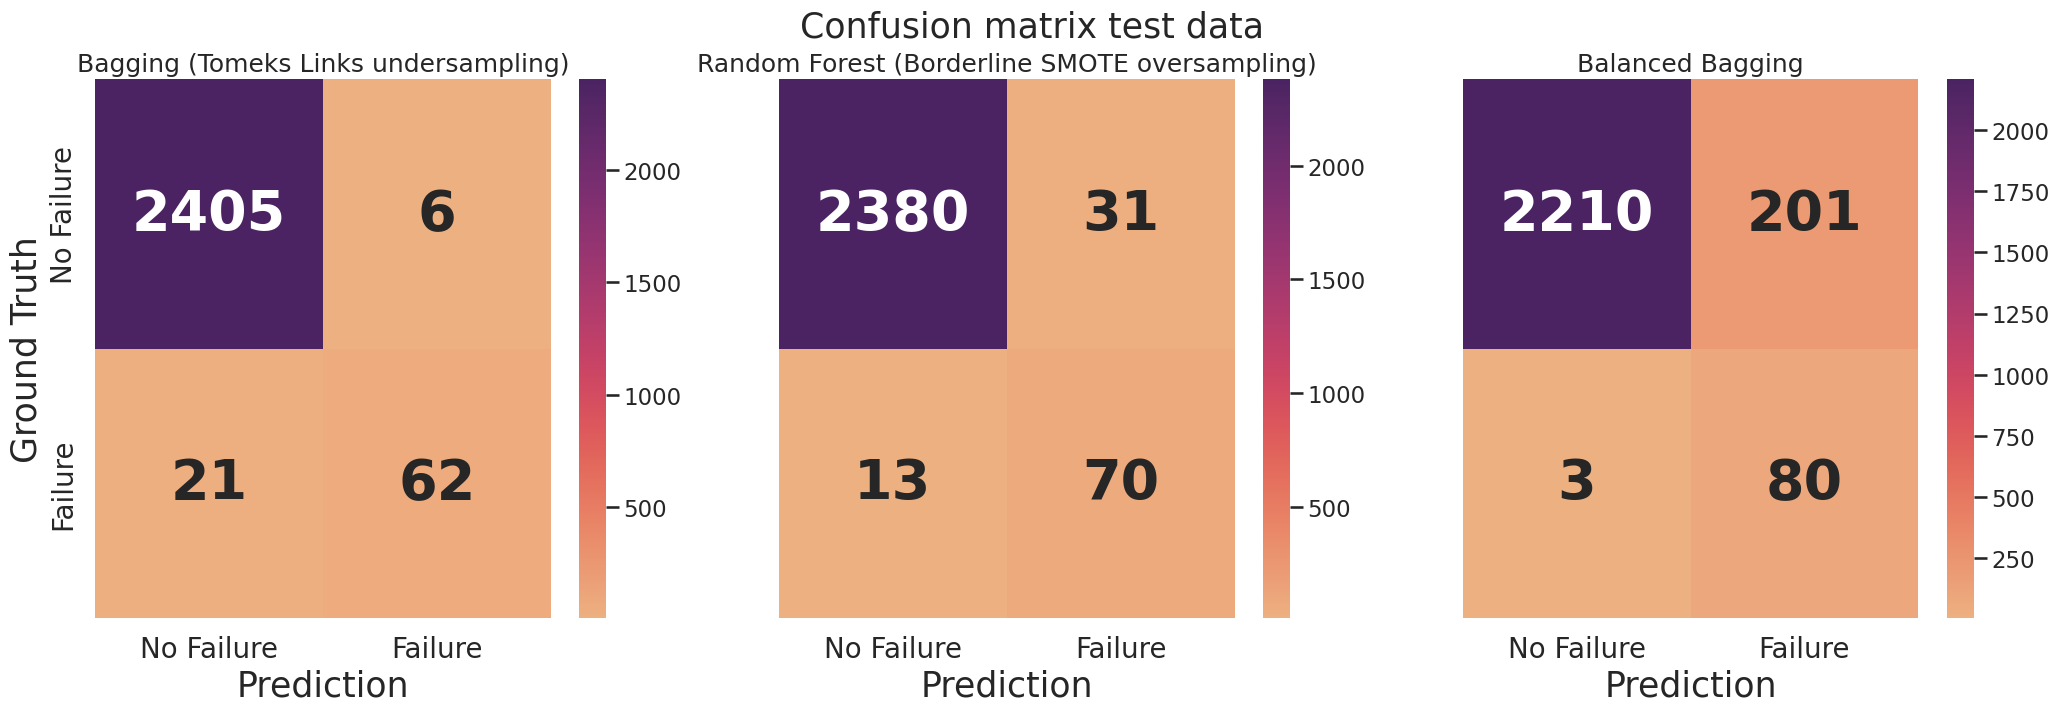

In [47]:
fig, axes = plt.subplots(1, 3, figsize=[25,7])
fig.suptitle('Confusion matrix test data', fontsize=25)
axes.flatten()
j=0

for model in [bag_model, rf_model, bal_bag_model]:
    y_pred = model.predict(X_test)
    # Confusion matrix test data
    sns.set_context('talk')
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='flare', annot_kws={"size": 40, "weight": "bold"}, ax=axes[j])

    labels = ['No Failure', 'Failure']
    axes[j].set_xticklabels(labels, fontsize=20)
    axes[j].set_yticklabels(['',''], fontsize=20)
    axes[j].set_xlabel('Prediction', fontsize=25)
    j += 1

axes[0].set_yticklabels(labels, fontsize=20)
axes[0].set_ylabel('Ground Truth', fontsize=25)
axes[0].set_title('Bagging (Tomeks Links undersampling)')
axes[1].set_title('Random Forest (Borderline SMOTE oversampling)')
axes[2].set_title('Balanced Bagging')
plt.show()

<span style="color:#26488F; font-size:22px; font-weight: bold;">  Roc and precision-recall curves </span>


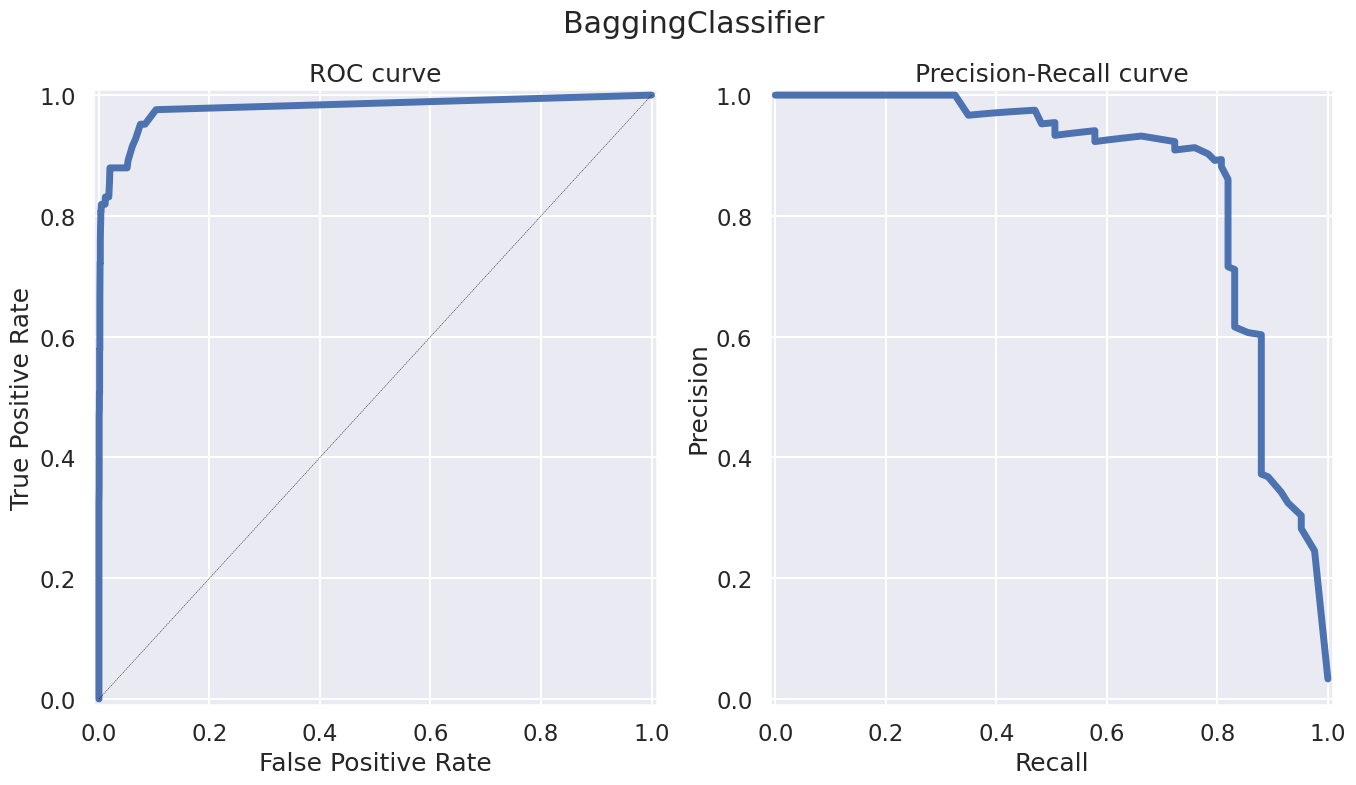

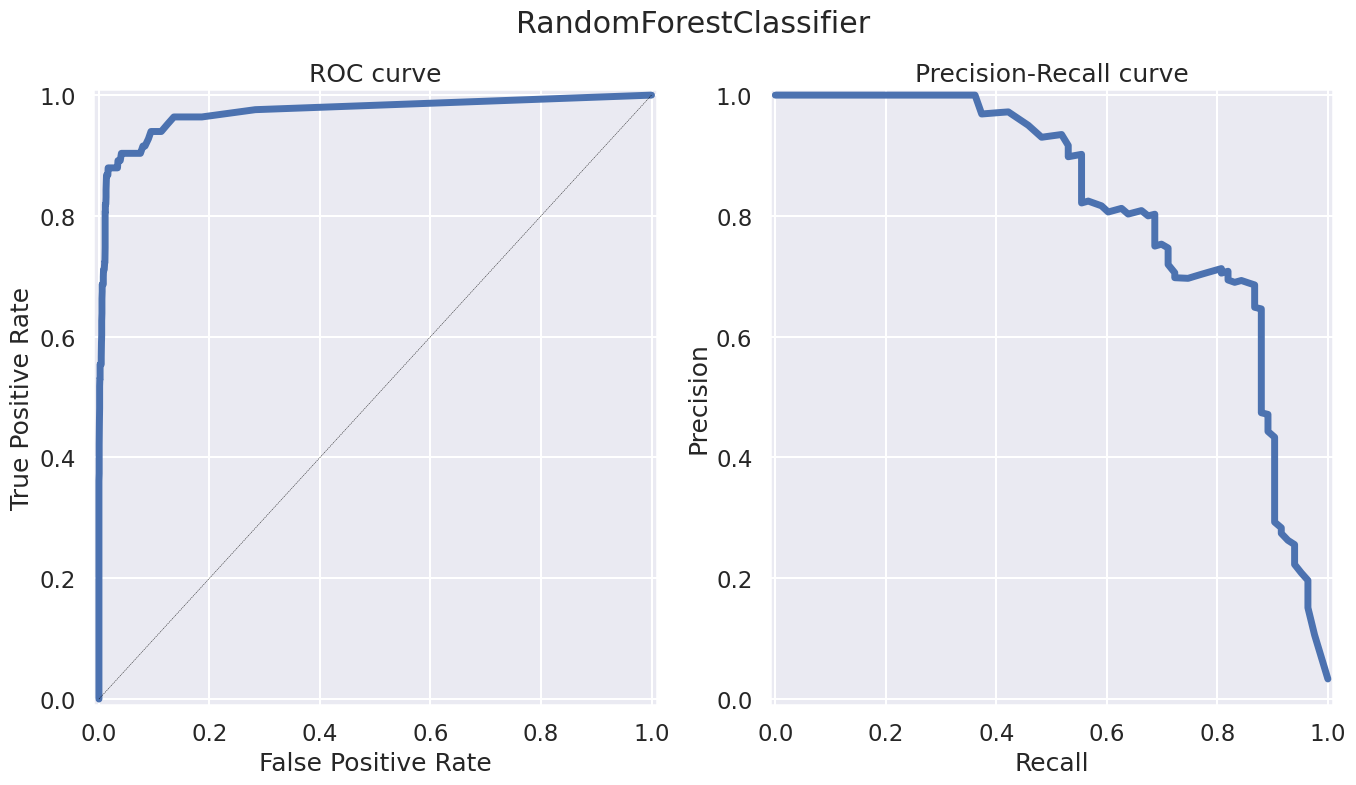

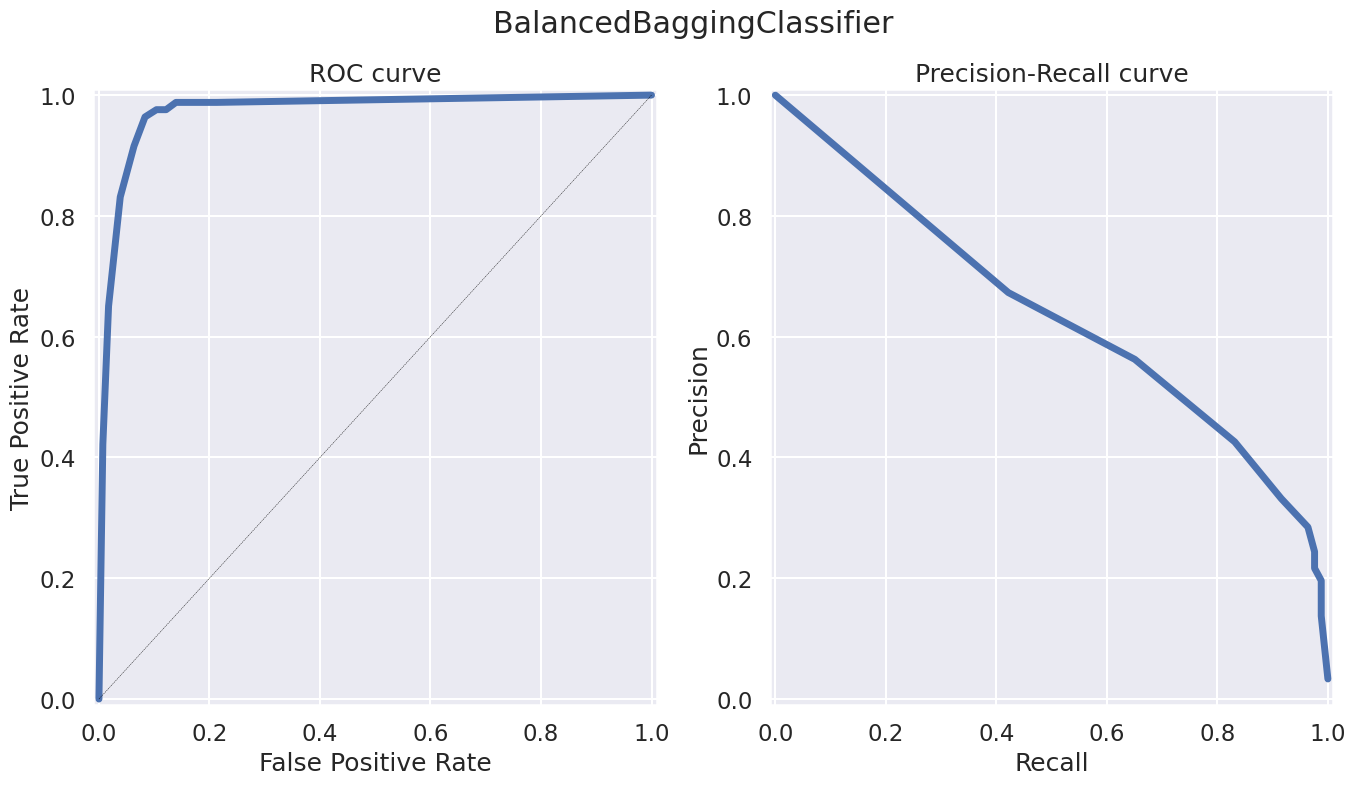

In [48]:
# Roc curve
def roc_prec_recall_curves(model):
    fig, axList = plt.subplots(ncols=2)
    fig.set_size_inches(16, 8)

    y_prob = model.predict_proba(X_test)

    # ROC-AUC curve
    ax = axList[0]
    fpr, tpr, thresholds = roc_curve(y_test, y_prob[:,1])
    ax.plot(fpr, tpr, linewidth=5)
    ax.plot([0, 1], [0, 1], ls='--', color='black', lw=.3)
    ax.set(xlabel='False Positive Rate',
           ylabel='True Positive Rate',
           xlim=[-.01, 1.01], ylim=[-.01, 1.01],
           title='ROC curve')
    ax.grid(True)

    # Precision-recall curve
    ax = axList[1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob[:,1])
    ax.plot(recall, precision, linewidth=5)
    ax.set(xlabel='Recall', ylabel='Precision',
           xlim=[-.01, 1.01], ylim=[-.01, 1.01],
           title='Precision-Recall curve')
    ax.grid(True)
    plt.suptitle(str(model).split('(')[0])

roc_prec_recall_curves(bag_model)
roc_prec_recall_curves(rf_model)
roc_prec_recall_curves(bal_bag_model)
plt.show()

Those plots are using a decision threshold of 0.5 when classiying. As mentioned before, we can play with this number to get a higher recall or precision, considering that there is always a trade-off between them. Let's do that:

<span style="color:#26488F; font-size:22px; font-weight: bold;">  Precision-Recall wrt decision threshold </span>

First, let's check the classification report of the bagigng tomek links model once again:

In [49]:
# Classification report
print(classification_report(y_test, y_pred_bag))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2411
           1       0.91      0.75      0.82        83

    accuracy                           0.99      2494
   macro avg       0.95      0.87      0.91      2494
weighted avg       0.99      0.99      0.99      2494



With this model, for the minority class (failure) we obtain a recall of 0.75 and a precision of 0.91. The algorithm classifies using a threshold of 0.5, meaning that if the probability of a certain instance of being class 1 (failure) is 0.51, it will be classied as failure. On the other hand, if it is less than 0.5 it will be classify as not failure.

We can change this threshold to obtain higher recall or precision scores, depending on what we are trying to achieve. For instace, setting a decision threshold at 0.6 would decrease recall and increase precision, and viceversa.

In the curves below, we can see the trade off between recall and precision (for failure class) by changing the decision threshold.

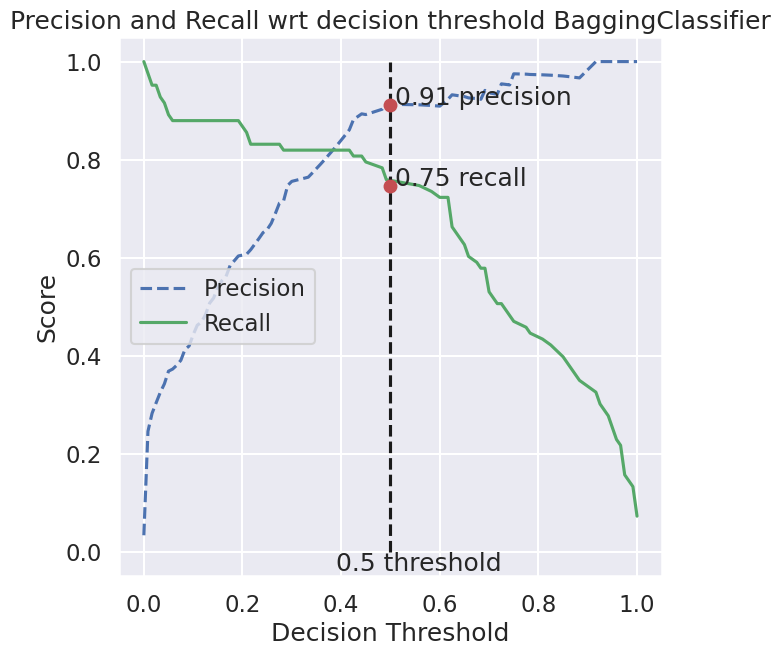

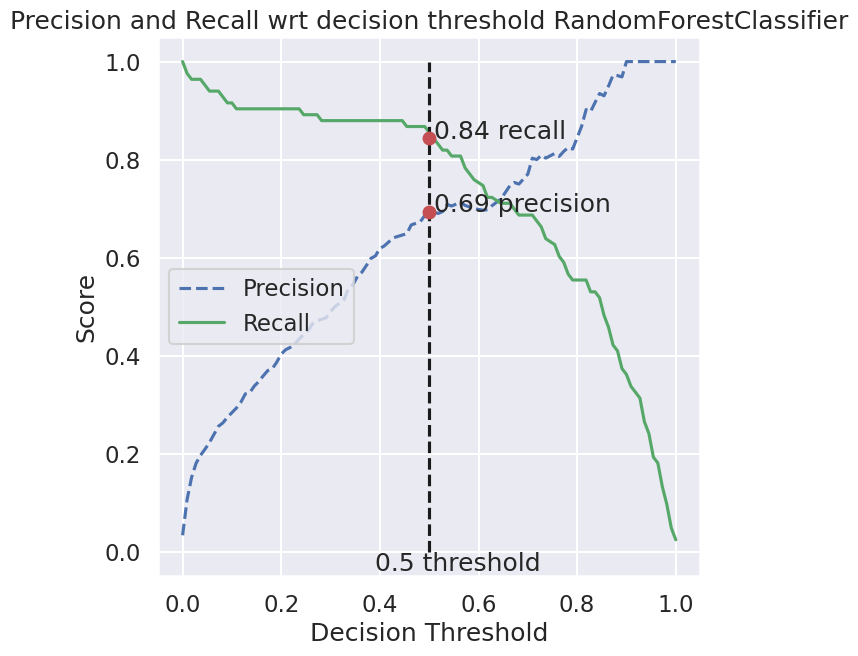

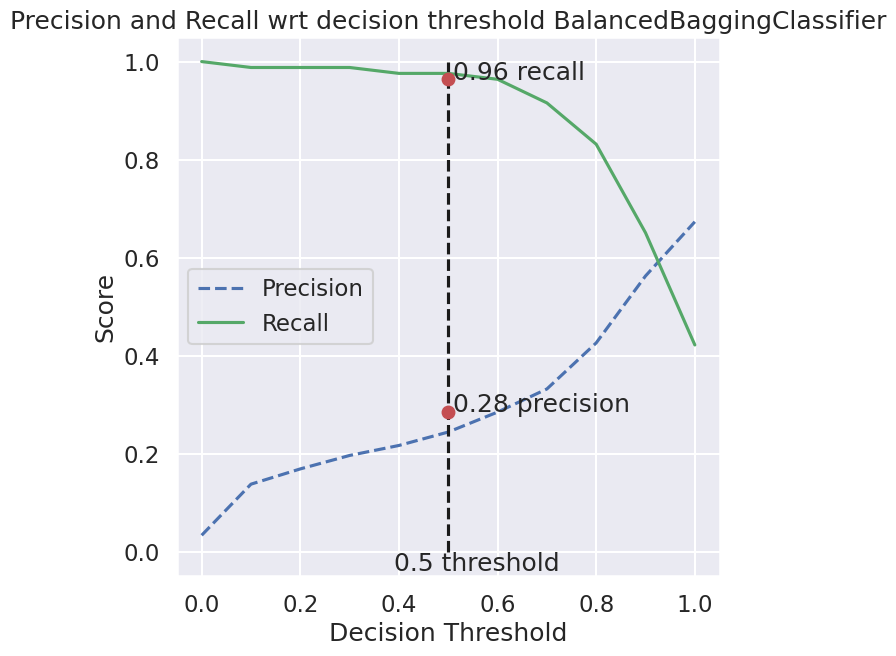

In [50]:
def plot_precision_recall_threshold(model):
    y_pred = model.predict_proba(X_test)[:,1]
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred)

    plt.figure(figsize=(7, 7))
    plt.title("Precision and Recall wrt decision threshold " + str(model).split('(')[0])
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
    plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
    plt.plot([0.5, 0.5], [0, 1], 'k--')
    plt.ylabel("Score")
    plt.xlabel("Decision Threshold")
    plt.legend(loc='center left')

    y_pred = model.predict(X_test)
    metrics = precision_recall_fscore_support(y_test, y_pred)
    precision = metrics[0][1]
    recall = metrics[1][1]

    # Precision score at 0.5 threshold
    plt.plot(0.5, precision, 'or')
    plt.annotate(f'{precision:.2f} precision', (0.51, precision))
    # Recall score at 0.5 threshold
    plt.plot(0.5, recall, 'or')
    plt.annotate(f'{recall:.2f} recall', (0.51, recall))
    plt.annotate('0.5 threshold', (0.39, -0.04))

plot_precision_recall_threshold(bag_model)
plot_precision_recall_threshold(rf_model)
plot_precision_recall_threshold(bal_bag_model)

plt.show()

- In the bagging tomeks links moel, with a default 0.5 threshold, we obtain a 0.75 recall and 0.91 precision score, just as seen in the classification report above.
- In the Balanced Bagging, with a 0.5 decision threshold, we obtain a much higher recall (0.96), but lower precision (0.28).


We can move the decision threshold to achieve the desired trade-off of precision-recall. Since we are trying to predict machine failure, the minority class (class failure) should be more important. Hence, we aim at higher recall at the expense of lower precision. In my opinion, it is better to have some false positives than not predict a failure.

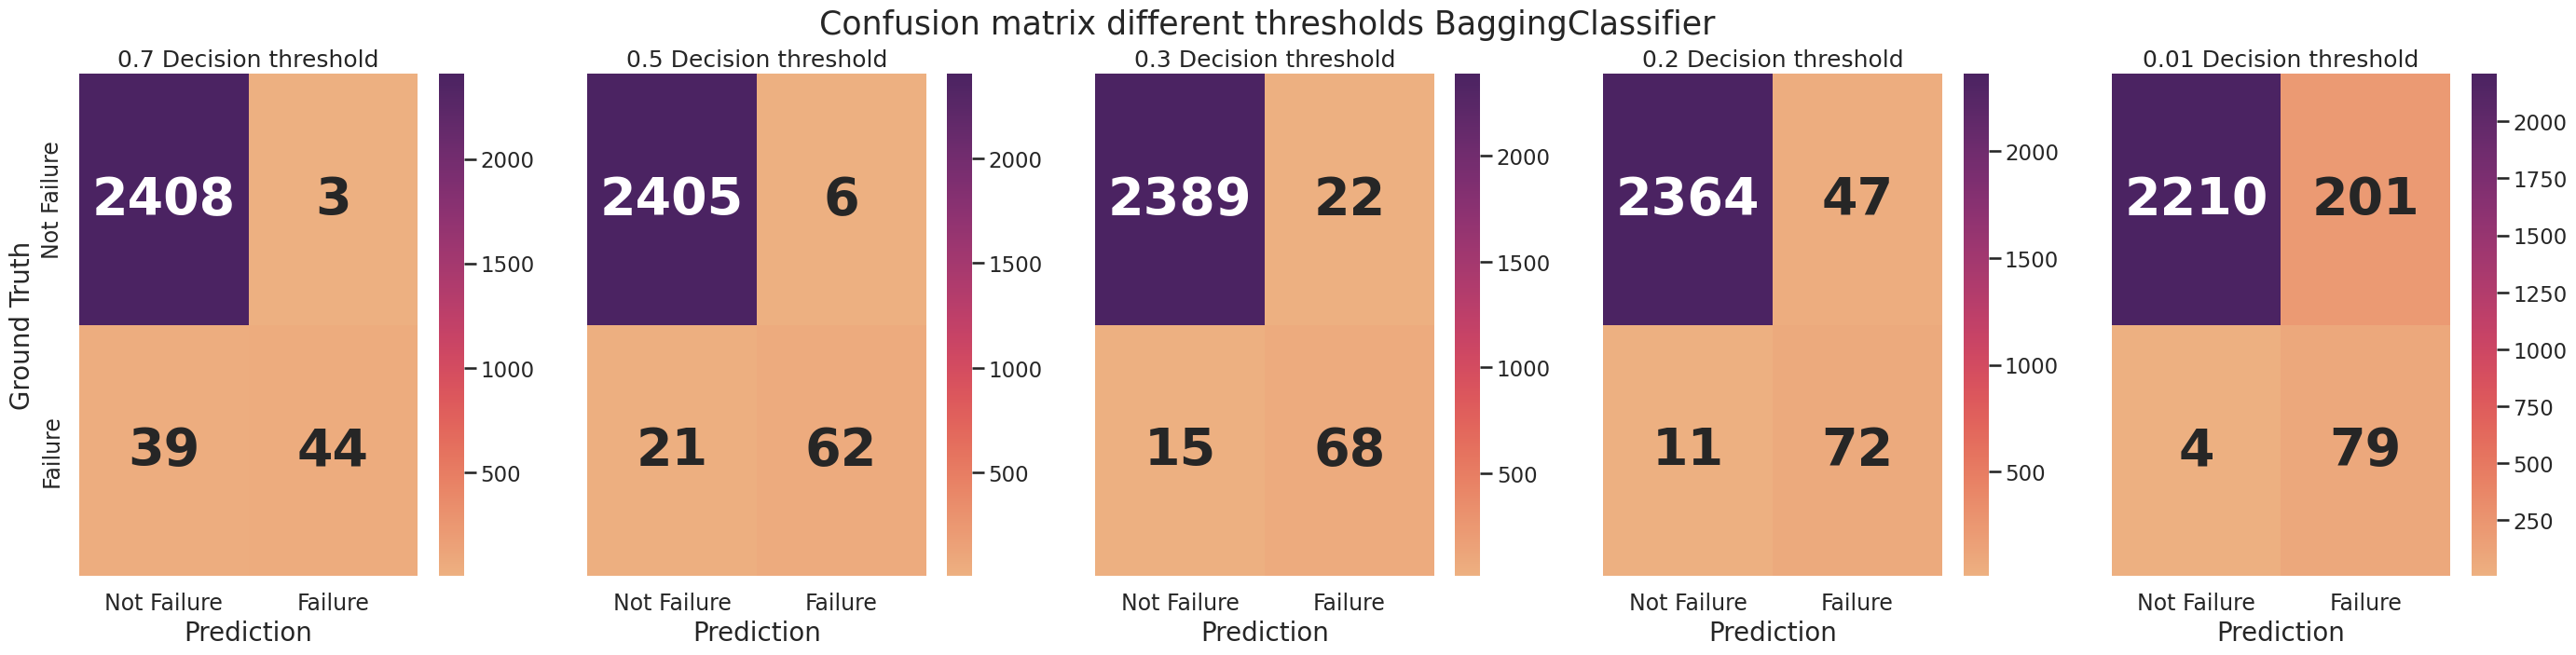

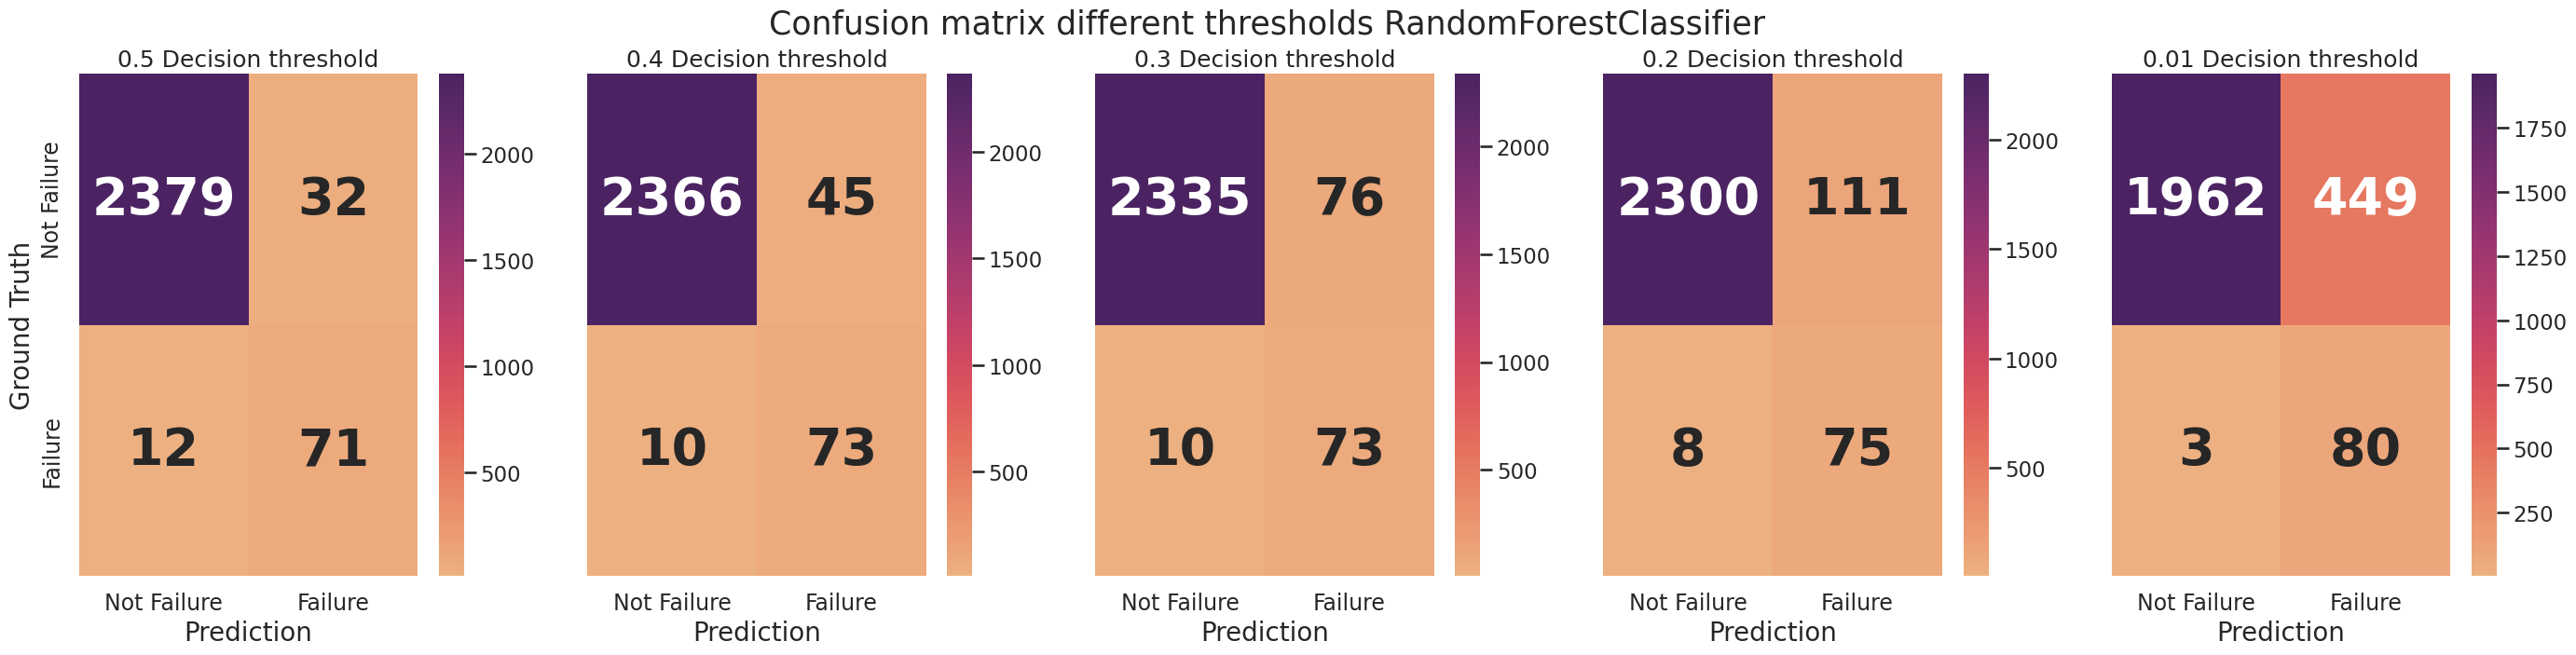

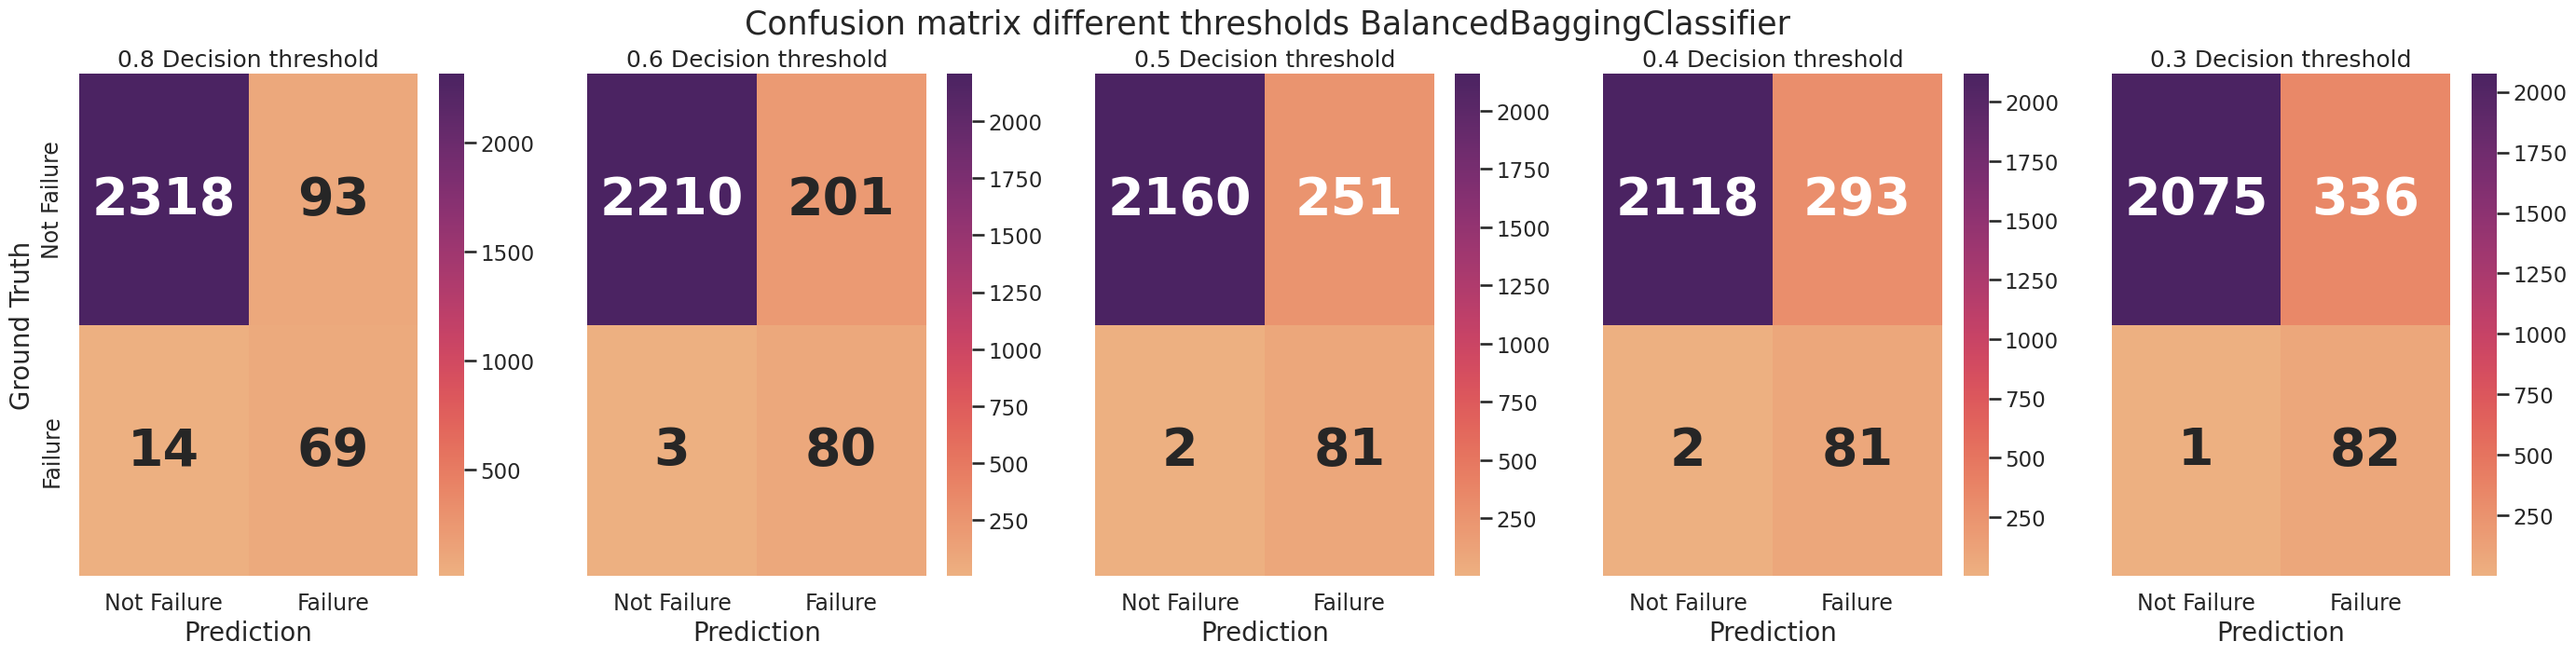

In [51]:
def confusion_matrix_threshold(model, threshold:list):
    # Prediction probabilities with different thresholds
    y_pred_dt = (model.predict_proba(X_test)[:,1] >= threshold[0]).astype(bool).astype(int)
    y_pred_dt_2 = (model.predict_proba(X_test)[:,1] >= threshold[1]).astype(bool).astype(int)
    y_pred_dt_3 = (model.predict_proba(X_test)[:,1] >= threshold[2]).astype(bool).astype(int)
    y_pred_dt_4 = (model.predict_proba(X_test)[:,1] >= threshold[3]).astype(bool).astype(int)
    y_pred_dt_5 = (model.predict_proba(X_test)[:,1] >= threshold[4]).astype(bool).astype(int)

    # Confusion matrices with different thresholds
    cm_dt = confusion_matrix(y_test, y_pred_dt)
    cm_dt_2 = confusion_matrix(y_test, y_pred_dt_2)
    cm_dt_3 = confusion_matrix(y_test, y_pred_dt_3)
    cm_dt_4 = confusion_matrix(y_test, y_pred_dt_4)
    cm_dt_5 = confusion_matrix(y_test, y_pred_dt_5)

    # Plotting confusion matrices
    fig, ax = plt.subplots(1,5,figsize=(34,7))
    ax.flatten()
    fig.suptitle('Confusion matrix different thresholds ' + str(model).split('(')[0], fontsize=25)

    sns.heatmap(cm_dt, annot=True, fmt='d', cmap='flare', annot_kws={"size": 40, "weight": "bold"}, ax=ax[0])
    sns.heatmap(cm_dt_2, annot=True, fmt='d', cmap='flare', annot_kws={"size": 40, "weight": "bold"}, ax=ax[1])
    sns.heatmap(cm_dt_3, annot=True, fmt='d', cmap='flare', annot_kws={"size": 40, "weight": "bold"}, ax=ax[2])
    sns.heatmap(cm_dt_4, annot=True, fmt='d', cmap='flare', annot_kws={"size": 40, "weight": "bold"}, ax=ax[3])
    sns.heatmap(cm_dt_5, annot=True, fmt='d', cmap='flare', annot_kws={"size": 40, "weight": "bold"}, ax=ax[4])

    ax[0].set_title(f'{threshold[0]} Decision threshold')
    ax[1].set_title(f'{threshold[1]} Decision threshold')
    ax[2].set_title(f'{threshold[2]} Decision threshold')
    ax[3].set_title(f'{threshold[3]} Decision threshold')
    ax[4].set_title(f'{threshold[4]} Decision threshold')

    labels = ['Not Failure', 'Failure']
    for i in [0,1,2,3,4]:
        ax[i].set_xticklabels(labels, fontsize=17)
        ax[i].set_xlabel('Prediction', fontsize=20)
        ax[i].set_yticklabels(['',''])

    ax[0].set_ylabel('Ground Truth', fontsize=20)
    ax[0].set_yticklabels(labels, fontsize=17)

confusion_matrix_threshold(bag_model, [0.7, 0.5, 0.3, 0.2, 0.01])
confusion_matrix_threshold(rf_model, [0.5, 0.4, 0.3, 0.2, 0.01])
confusion_matrix_threshold(bal_bag_model, [0.8, 0.6, 0.5, 0.4, 0.3])
plt.show()

Let's explain the results...

Decision threshold 0.5:
- Balanced bagging classifier was not able to predict only 2 failures. 251 times classified no failures as failures.
- Bagging Tomek Links was not able to predict 21 failures. But, it misclassified no failures only 6 times.
- Random forest borderline SMOTE was not able to predict 12 failures. It misclassified no failures 32 times.
    
**Takeaways**:

The bagging tomek links model is not able to reduce the recall on failures lower than 95.18%. Even with a decision threshold of 0.01 (which makes no sense) it still misclassified 4 failures and had 201 false positives. On the other, balanced bagging with a decision threshold of 0.6 is able to have better recall (96.25%) and the same number of false positives (201). Moreover, it is able to reduce the recall down to 98.8% (only 1 misclassified failure) at the expense of increasing the number of positives (336). But, it is the only one of the three models to get this very high recall.


<span style="color:#26488F; font-size:18px; font-weight: bold;">  Conclusions </span>

In my opinion, the experts from the maintenance and manufacturing departments should be the ones who choose the model in accordance with their objectives.
- If they are looking for the highest failure detection possible, they should go with the balanced bagging model, thou they would be sacrificing precision with lots of false positives.
- If they want a balance between precision and recall, perhaps they could choose between the bagging model 0.4 decision threshold or the random forest model with 0.5  threshold.
- Maybe they do not care much about predicting every failure, but when they do, they want the highest precision possible. In that case, it would be better to opt for the bagging tomek links classifier with a bit higher decision threshold.

So, the selection of the model depends on the application and desired outcomes.


<span style="color:#26488F; font-size:22px; font-weight: bold;">  Saving Models </span>

In [52]:
# with open("Bagging_binary.pkl","wb") as files:
#     pickle.dump(bag_model,files)
# with open("RandomForest_binary.pkl","wb") as files:
#     pickle.dump(rf_model,files)
# with open("BalancedBagging_binary.pkl","wb") as files:
#     pickle.dump(bal_bag_model,files)

<span style="color:#26488F; font-size:28px; font-weight: bold;">  Modeling with 'Failure Type' target </span>

Now, let's treat the problem as a multiclass one.

# Stratified Split

In [53]:
X = df.drop(['Target', 'Failure Type'], axis=1)
y = df['Failure Type']

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.25, random_state=42)

for train_index, test_index in sss.split(X, y):
    X_train, X_test = X.loc[train_index], X.loc[test_index]
    y_train, y_test = y.loc[train_index], y.loc[test_index]

print('Checking the stratified split...')
print('Target proportion in original dataset:')
print(df['Failure Type'].value_counts(normalize=True))

print('Target proportion in y_train dataset:')
print(y_train.value_counts(normalize=True))

print('Target proportion in y_test dataset:')
print(y_test.value_counts(normalize=True))

Checking the stratified split...
Target proportion in original dataset:
Failure Type
0.0    0.966911
4.0    0.011230
1.0    0.009526
3.0    0.007821
2.0    0.004512
Name: proportion, dtype: float64
Target proportion in y_train dataset:
Failure Type
0.0    0.966974
4.0    0.011231
1.0    0.009493
3.0    0.007755
2.0    0.004546
Name: proportion, dtype: float64
Target proportion in y_test dataset:
Failure Type
0.0    0.966720
4.0    0.011227
1.0    0.009623
3.0    0.008019
2.0    0.004411
Name: proportion, dtype: float64


The proportions are similar. Therefore, it was correctly splitted.

# Balanced Models

Fitting BalancedRandomForestClassifier(n_jobs=-1, random_state=42)
ROC AUC test set: 0.9806005768173198

Fitting BalancedBaggingClassifier(n_jobs=-1, random_state=42)
ROC AUC test set: 0.9655364264073679

Fitting RUSBoostClassifier(random_state=42)
ROC AUC test set: 0.6205593225651108

Fitting EasyEnsembleClassifier(random_state=42)
ROC AUC test set: 0.9684325637037592



Text(0.5, 1.0, 'Easy Ensemble')

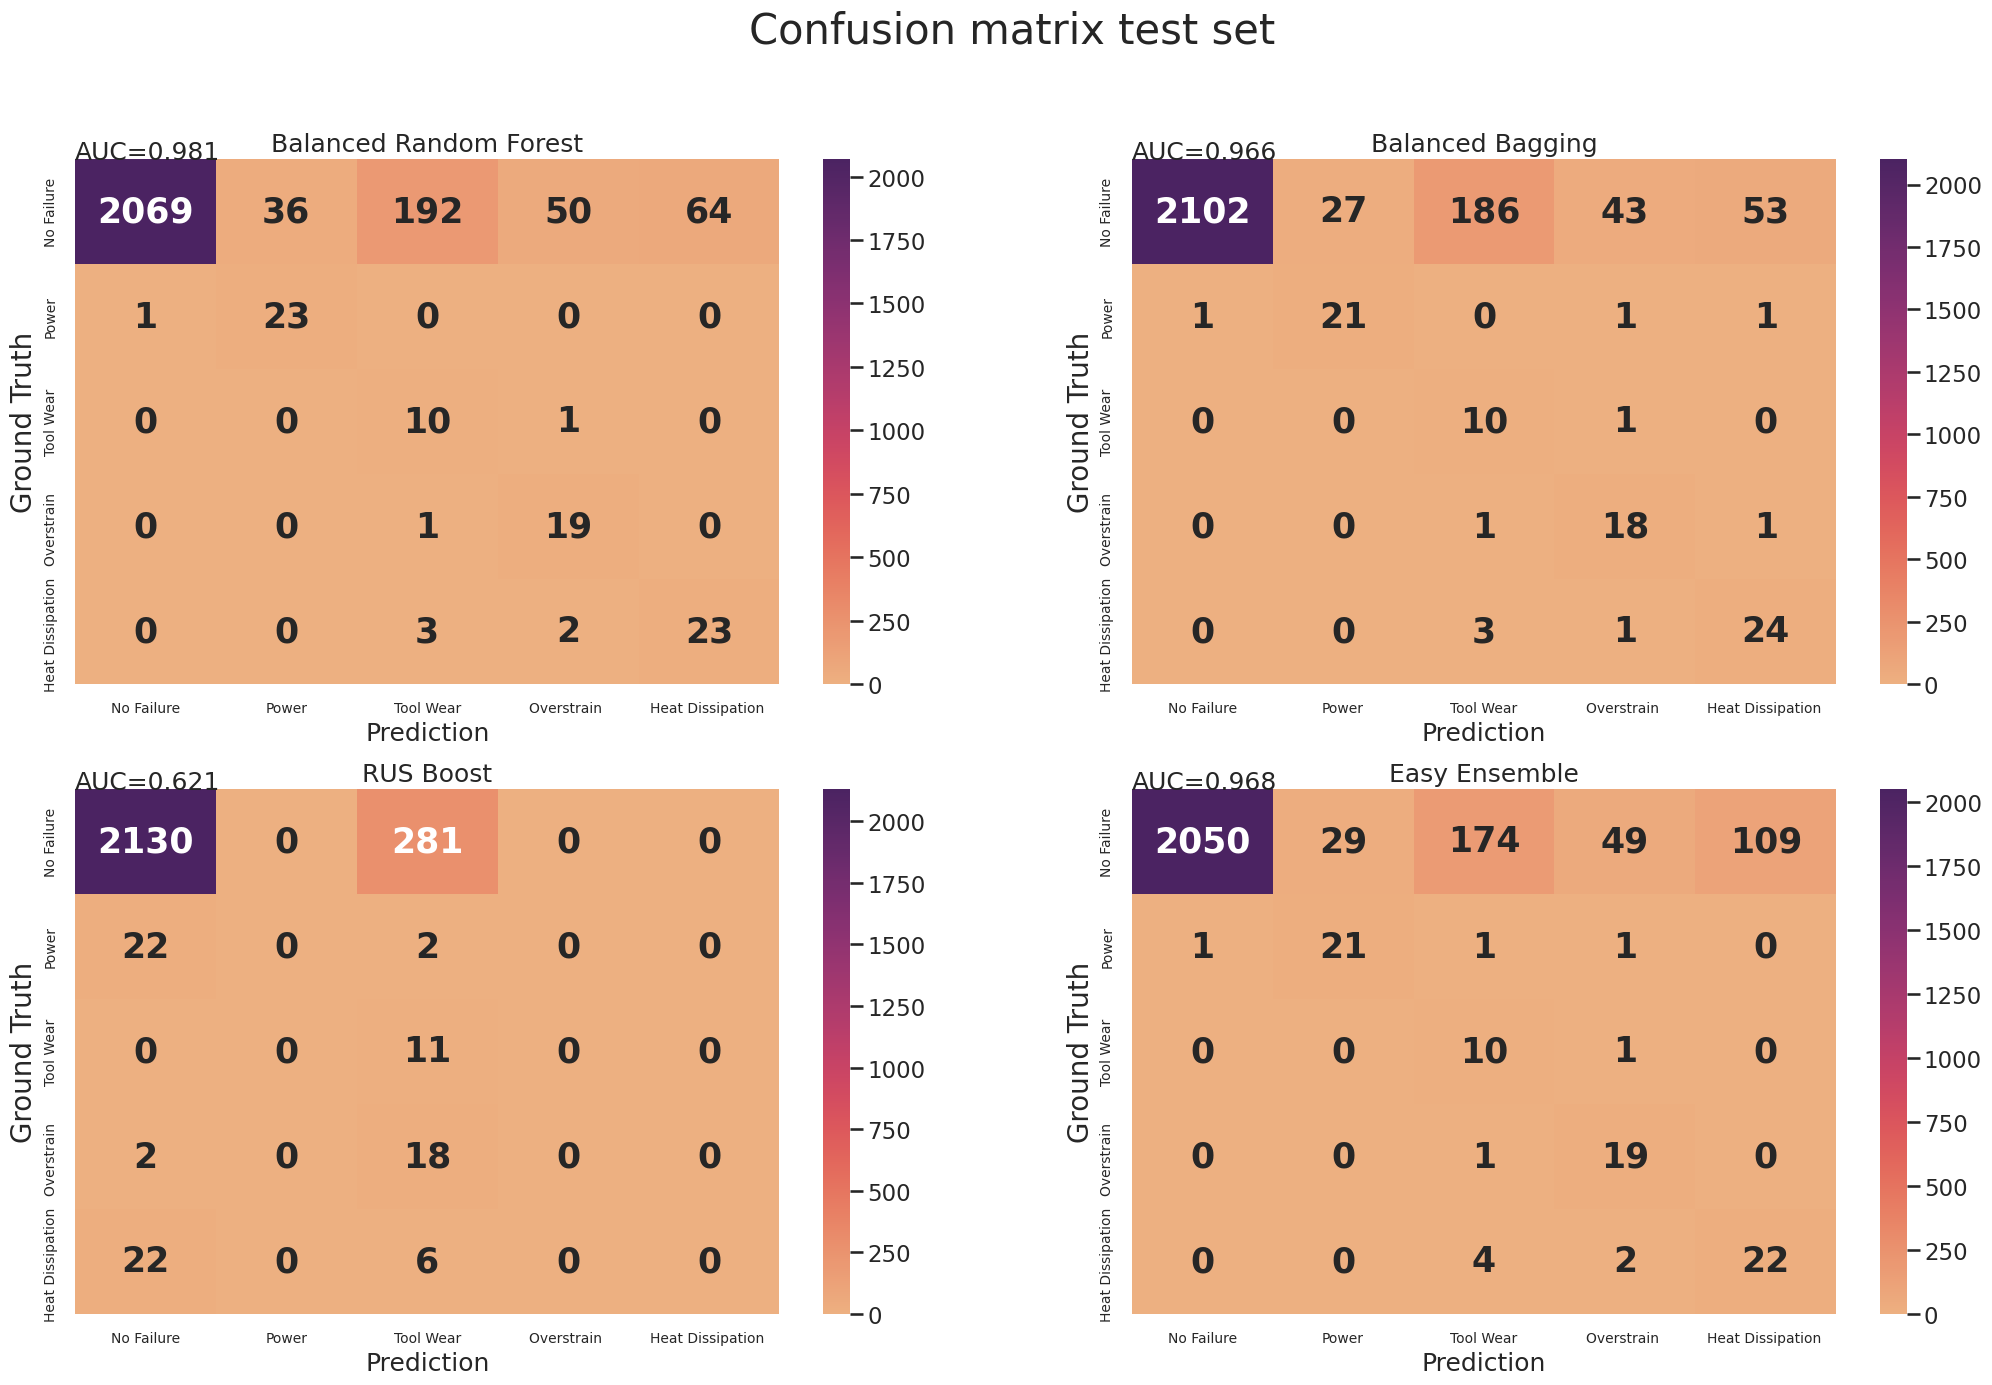

In [54]:
brfc = BalancedRandomForestClassifier(random_state=42, n_jobs=-1)
bbc = BalancedBaggingClassifier(random_state=42, n_jobs=-1)
RUSB = RUSBoostClassifier(random_state=42)
EEC = EasyEnsembleClassifier(random_state=42)

fig, axes = plt.subplots(2, 2, figsize=[25,15])
fig.suptitle('Confusion matrix test set', fontsize=30)
# axes.flatten()
i=0
j=0
for model in [brfc, bbc, RUSB, EEC]:
    print('Fitting', model)
    model = model.fit(X_train, y_train)

    cv = StratifiedShuffleSplit(n_splits=5, test_size=0.25)

    y_pred = model.predict(X_test)
    y_preb_probs = model.predict_proba(X_test)

    print(f'ROC AUC test set: {roc_auc_score(y_test, y_preb_probs, average="macro", multi_class="ovr")}')

    print()

    if j == 2:
        j = 0
        i = 1

    sns.set_context('talk')
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='flare', annot_kws={"size": 25, "weight": "bold"}, ax=axes[i,j])

    labels =  ['No Failure',
               'Power',
               'Tool Wear',
               'Overstrain ',
               'Heat Dissipation ']
    axes[i,j].set_xticklabels(labels, fontsize=10);
    axes[i,j].set_yticklabels(labels, fontsize=10);
    axes[i,j].set_ylabel('Ground Truth', fontsize=20);
    axes[i,j].set_xlabel('Prediction')
    axes[i,j].annotate('AUC=' + str(round(roc_auc_score(y_test, y_preb_probs, average="macro", multi_class="ovr"),3)), xy=[0,0])
    j += 1

axes[0,0].set_title('Balanced Random Forest')
axes[0,1].set_title('Balanced Bagging')
axes[1,0].set_title('RUS Boost')
axes[1,1].set_title('Easy Ensemble')

Again, Balanced Random Forest and Balanced Bagging outpeformed the other two algorithms.

* Balanced Random Forest (Random Search)

In [55]:
brfc = BalancedRandomForestClassifier(random_state=42, n_jobs=-1)

params = {'n_estimators': np.arange(150, 400, 50),
               'max_depth': np.arange(10, 50, 10),
               'min_samples_split': [2, 4, 6],
               'criterion': ['gini', 'entropy'],
               'min_samples_leaf': [1, 2, 3, 4],
               'max_features': ['sqrt', 'log2']
            }

random_search = RandomizedSearchCV(brfc, params, cv=3,
                                   n_iter=100, random_state=42, n_jobs=-1)

random_search = random_search.fit(X_train, y_train)

# Best parameters from random search
print(random_search.best_params_)

{'n_estimators': np.int64(350), 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': np.int64(30), 'criterion': 'gini'}


<span style="color:#26488F; font-size:18px; font-weight: bold;">  Balanced Random Forest (Grid Search) </span>

In [56]:
brfc = BalancedRandomForestClassifier(max_features='sqrt', random_state=42, n_jobs=-1)

params = {'n_estimators': [40, 50, 60],
               'max_depth': [15, 20, 25],
               'min_samples_leaf': [1, 2]
            }

grid_search = GridSearchCV(brfc, params, cv=cv,
                           n_jobs=-1)

grid_search = grid_search.fit(X_train, y_train)
# Best parameters from grid search
grid_search.best_params_

{'max_depth': 15, 'min_samples_leaf': 1, 'n_estimators': 50}

<span style="color:#26488F; font-size:22px; font-weight: bold;">  Training both models with the best hyperparameters </span>

In [57]:
# Balanced Random Forest
brfc = BalancedRandomForestClassifier(n_estimators=40, max_depth=15, min_samples_leaf=1,
                                     max_features='sqrt', random_state=42, n_jobs=-1)

brfc = brfc.fit(X_train, y_train)
y_pred_brfc = brfc.predict(X_test)
y_pred_probs_brfc = brfc.predict_proba(X_test)

# Balanced Bagging
bbc = BalancedBaggingClassifier(n_estimators=13, random_state=42, n_jobs=-1)
bbc = bbc.fit(X_train, y_train)
y_pred_bbc = bbc.predict(X_test)
y_pred_probs_bbc = bbc.predict_proba(X_test)

<span style="color:#26488F; font-size:18px; font-weight: bold;">  Scores </span>

In [58]:
# Balanced Random Forest scores
print('Results for Balanced Random Forest')
print(classification_report(y_test, y_pred_brfc))
print('Macro roc auc (OvR): ', roc_auc_score(y_test, y_pred_probs_brfc, average="macro", multi_class="ovr"))
print('='*53)
print()

# Balanced Bagging scores
print('Results for Balanced Bagging')
print(classification_report(y_test, y_pred_bbc))
print('Macro roc auc (OvR): ', roc_auc_score(y_test, y_pred_probs_bbc, average="macro", multi_class="ovr"))

Results for Balanced Random Forest
              precision    recall  f1-score   support

         0.0       1.00      0.85      0.92      2411
         1.0       0.40      0.96      0.56        24
         2.0       0.05      0.91      0.09        11
         3.0       0.25      0.95      0.39        20
         4.0       0.29      0.93      0.44        28

    accuracy                           0.86      2494
   macro avg       0.40      0.92      0.48      2494
weighted avg       0.98      0.86      0.90      2494

Macro roc auc (OvR):  0.9794518976665397

Results for Balanced Bagging
              precision    recall  f1-score   support

         0.0       1.00      0.87      0.93      2411
         1.0       0.47      0.96      0.63        24
         2.0       0.05      0.91      0.09        11
         3.0       0.31      0.90      0.46        20
         4.0       0.28      0.82      0.41        28

    accuracy                           0.87      2494
   macro avg       0.42  

**Conclusion:** Balance Random Forest has a slightly lower ROC AUC (OvR) but higher f1 score (both macro and weighted).
Let's take a look at the confusion matrices:

# Confusion matrix

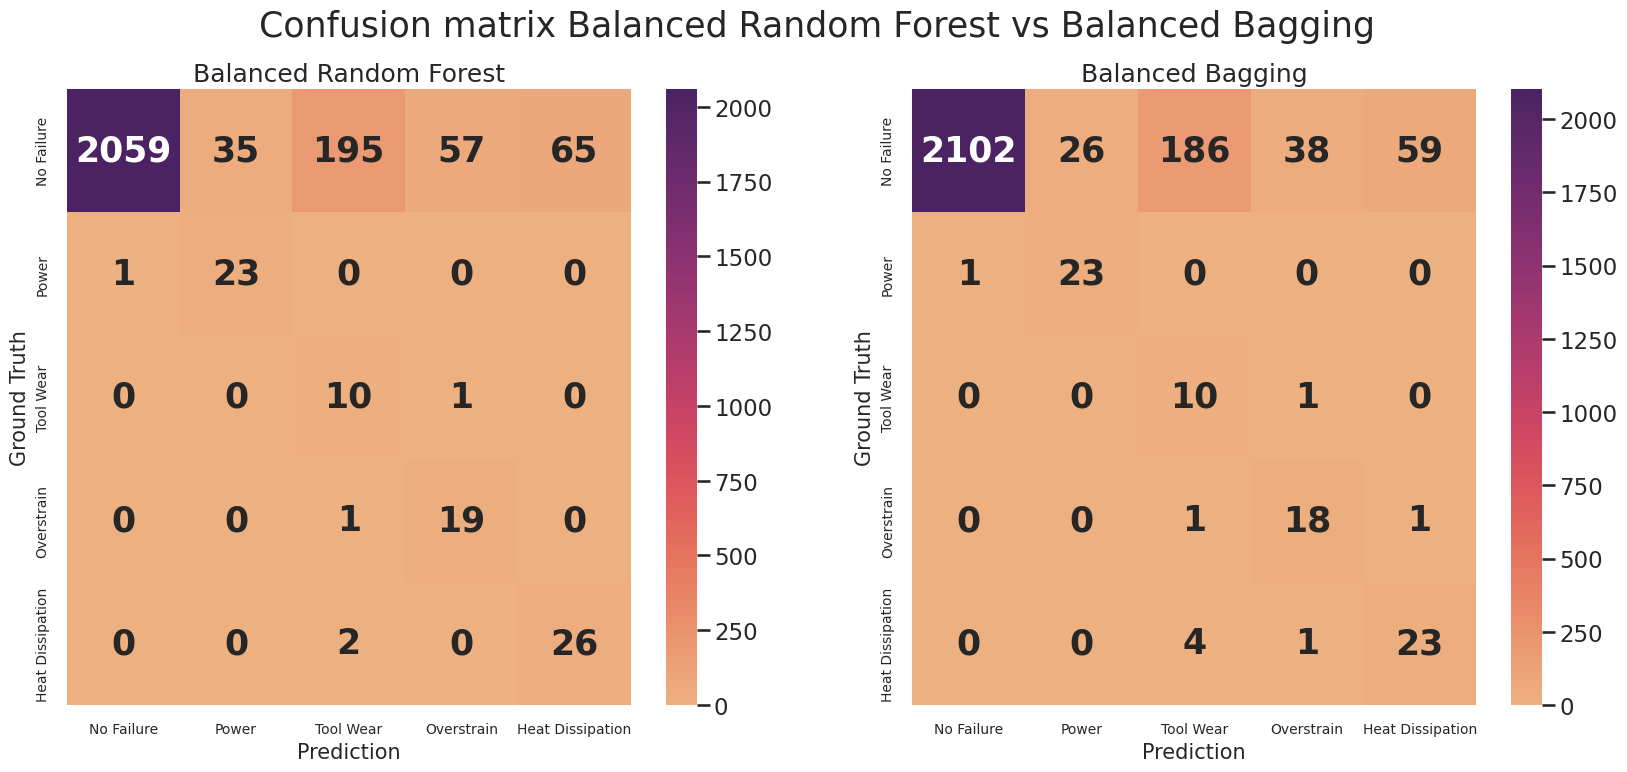

In [59]:
cm_brfc = confusion_matrix(y_test, y_pred_brfc)
cm_bbc = confusion_matrix(y_test, y_pred_bbc)

# Plotting confusion matrices
fig, ax = plt.subplots(1,2,figsize=(20,8))
ax.flatten()
fig.suptitle('Confusion matrix Balanced Random Forest vs Balanced Bagging', fontsize=25)

sns.heatmap(cm_brfc, annot=True, fmt='d', cmap='flare', annot_kws={"size": 25, "weight": "bold"}, ax=ax[0])
sns.heatmap(cm_bbc, annot=True, fmt='d', cmap='flare', annot_kws={"size": 25, "weight": "bold"}, ax=ax[1])

ax[0].set_title('Balanced Random Forest')
ax[1].set_title('Balanced Bagging')

labels =  ['No Failure',
           'Power',
           'Tool Wear',
           'Overstrain',
           'Heat Dissipation']

for i in [0,1]:
    ax[i].set_xticklabels(labels, fontsize=10);
    ax[i].set_yticklabels(labels, fontsize=10);
    ax[i].set_ylabel('Ground Truth', fontsize=15);
    ax[i].set_xlabel('Prediction', fontsize=15)

# Conclusions

The performance of both models is really close to each other.
* There is a bit of a tendency to misclassify Heat Dissipation Failure as Tool Wear Failure.
* Balanced Random Forest is able to detect every failure, although sometimes it misclassifies them. Balanced Bagging was not able to detect one power failure.

I would pick Balanced Bagging classifier for the following reasons:
* The recall scores are slightly lower. But, we can see in the confusion matrix that the precision for each class is higher.
* Since we know that sometimes Heat Dissipation Failures are classified as Tool Wear Failures, we might take the appropriate actions to deal with such maintenance in real-world applications. In other words, if we predict a Heat Dissipation Failure, we might check the tool wear as well.
* However, such a decision should be supported by the maintenance and manufacturing teams. It is difficult to pick without taking into account the real application. As mentioned before, they might want to get higher precision and reducing recall.

# Save Model

In [60]:
with open("BalBagging_multiclass.pkl","wb") as files:
    pickle.dump(bbc,files)
with open("BalRandomForest_multiclass.pkl","wb") as files:
    pickle.dump(brfc,files)

from google.colab import files
files.download("BalBagging_multiclass.pkl")
files.download("BalRandomForest_multiclass.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [61]:
with open("BalRandomForest_multiclass.pkl","wb") as files:
    pickle.dump(brfc,files)

In [62]:
from google.colab import files
files.download("BalRandomForest_multiclass.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>